### Importing Essential Modules

In [1]:
import torch
import time
import librosa
import os
import random

from torch import nn
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.io import wavfile
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report


import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

### Loading Dataset

In [2]:
# Setting the dtype default to be float32, this is because MPS does not support float64
torch.set_default_dtype(torch.float32)

ALL_CLASSES = list("abcdefghijklmnopqrstuvwxyz0123456789")  # 36 classes; creates a list containing each letter
label_encoder = LabelEncoder() # maps each of the 36 characters to a number, starting with a --> 0
label_encoder.fit(ALL_CLASSES)
CLASS_NAMES = ALL_CLASSES #assigns the list to a new namel; CLASS_NAMES


class AudioAugment: #defining a class for augmentation
    """Apply random augmentations to mel spectorgrams during training"""
    def __call__(self, mel): #making the class callable

        """Time Masking: Randomly zero out time strips"""
        if random.random() > 0.5: #if there's over a 50% chance
            timeMask = random.randint(1, max(1, mel.shape[1] // 8)) #chooses a how many time frames, width, are going to be hidden at random (1/8th of the spectogram at most)
            timeStart = random.randint(0, mel.shape[1] - timeMask) #Chooses where the starting position for the blank strip
            mel[:, timeStart:timeStart + timeMask] = mel.min() #sets those time frames to a minimum value to erase that section of time

        """Frequency Masking: Rnadomly zero out frequency bands"""
        if random.random() > 0.5: #if there's over a 50% chance
            frequencyMask = random.randint(1, max(1, mel.shape[0] // 8)) #chooses a how many time frames, height, are going to be hidden at random (1/8th of the spectogram at most)
            frequencyStart = random.randint(0, mel.shape[0] - frequencyMask) #Chooses a random starting frequency
            mel[frequencyStart:frequencyStart + frequencyMask, :] = mel.min() #sets those time frames to a minimum value to erase that entire horizontal section of time

        """Random Noise"""
        if random.random() > 0.5:
            noise = np.random.normal(0, 0.01, mel.shape).astype(np.float32) #creates random Gaussian Noise which has the same shape as the spectogram
            mel = mel + noise #adds the noise to the spectogram

        return mel #returns the spectogram


"""This transform the audio signal into mel-spectrogram, which will be the input for CoATnet model to processed"""
class ToMelSpectrogram: #class definition (this class converts audio into spectogram images which the model will be able to process)
    """"Augmentation is only APPLIED during training only to prevent overfitting"""
    def __init__(self, augment=False, targetFrames=99, sampleRates=44100): #takes 3 input parameters; spectogram width will be 99, and the sample rate is set to 44100
        self.augment = augment #applying augmentations
        self.targetFrames = targetFrames
        self.sampleRates = sampleRates #audio quality

    def __call__(self, samples): #makes the class callable
        """Random pitch shift before spectrogram (training only)"""
        if self.augment and random.random() > 0.5:
            n_steps = random.uniform(-2, 2) # randomly shifting the between -2 and 2 semitones
            samples = librosa.effects.pitch_shift(samples, sr=self.sampleRates, n_steps=n_steps) #changes the pitch while simultaneously keeping the length constant

        """Random time stretch (training only)"""
        if self.augment and random.random() > 0.5:
            rate = random.uniform(0.9, 1.1) # randomly speeds or slows down the audio between 90% and 110%
            samples = librosa.effects.time_stretch(samples, rate=rate)
            # Trim or pad back to expected length
            originalLen = int(self.sampleRates * 1.0) #after the clip is modified, it is shortened or padded again to 1 second.
            if len(samples) > originalLen:
                samples = samples[:originalLen]
            else:
                samples = np.pad(samples, (0, originalLen - len(samples)), mode='constant')

        mel = librosa.feature.melspectrogram(y=samples, sr=self.sampleRates, n_mels=128, n_fft=2048, hop_length=225)
        """Convert power spectrogram to dB scale — better for model training"""
        melDb = librosa.power_to_db(mel, ref=np.max)

        """Capture attach/decay shape of each keystrokes"""
        delta  = librosa.feature.delta(melDb)
        delta2  = librosa.feature.delta(melDb, order=2)
        
        """Fix Melotrogram Length"""
        def fixLength(arr):
            cur = arr.shape[1]
            if cur < self.targetFrames:
                arr = np.pad(arr, ((0, 0), (0, self.targetFrames - cur)), mode='constant', constant_values=arr.min())
            elif cur > self.targetFrames:
                arr = arr[:, :self.targetFrames]
            return arr

        melDb = fixLength(melDb)
        delta = fixLength(delta)
        delta2 = fixLength(delta2)
        
        if self.augment:
            melDb = AudioAugment()(melDb)

        """Stack into (3, n_mels, T) - analogous to RGB channels"""
        stacked = np.stack([melDb, delta, delta2], axis=0).astype(np.float32)
        return stacked


"""Defining a dataset class to store audio data to train the model"""
class AudioDataset(torch.utils.data.Dataset): #defining a dataset class that is compatible with PyTorch DataLoader
    def __init__(self, dataDir, transform=None):
        """Setting the directory that contains audio data to be trained on"""
        self.dataDir = dataDir #stores the dataset Directory path
        self.transform = transform #stores the transformation function
        self.samples = [] #initilizing an empty list to hold the dataset entries
        for dirpath, _, filenames in os.walk(self.dataDir): #goes through all folders in the directory
            for filename in sorted(filenames): #loops through the files within each folder
                if filename.endswith(".wav"): #condition: if it ends with a .wav (audio)
                    filepath = os.path.join(dirpath, filename) #creates a full path to that audio file
                    label = os.path.basename(dirpath) # and uses the folder's name as a label
                    self.samples.append((filepath, label)) #stores the filepath and the label
        print(f"Dataset loaded: {len(self.samples)} samples across " # prints the summary of the dataset
              f"{len(set(l for _, l in self.samples))} classes")

    def __len__(self):
        return len(self.samples) #returns the length of samples/ number of samples

    def __getitem__(self, idx):
        filepath, label = self.samples[idx] #gets the filepath and label

        waveform, _ = librosa.load(filepath, sr = None, duration = 1.0, mono = True) #loads the audio file with the durartion being set to 1 second
        if self.transform:
            waveform = self.transform(waveform) #applying the spectogram transform -> should return (3, n_mels, T) numpy array

        """The waveform array already in dimension (C, H, W) - (3, H, W), we just need to convert manually from numpy array to torch tensor to keep the channel dim"""
        if isinstance(waveform, np.ndarray):
            waveform = torch.from_numpy(waveform)
        
        encodedLabel = label_encoder.transform([label])[0] #converts the label from a character to a number
        label  = torch.tensor(encodedLabel, dtype=torch.long) #converts the label to a PyTorch tensor
        return waveform, label #returns the spectogram + label

    @property #creates a property which will be used to access the labels
    def targets(self):
        """Returns list of all labels — required for stratified train/val split"""
        return [label for _, label in self.samples] #retruns the labels



"""Getting the largest number of frames and average sample rates out of all the audio in the dataset"""
def computeDatasetStats(rootDir):
    largestFrames = 0 # this will be used as a counter to track the maximum mel frames
    allMelFrames = [] # initializes an empty list for storing the statistics
    for dirpath, _, filenames in os.walk(rootDir): #loops through the database directory
        for filename in sorted(filenames): #loops through those subfiles
            if filename.endswith(".wav"): #if the name ends with .wav (audio)
                filepath = os.path.join(dirpath, filename)
                # print(f"Reading WAV File at path {filepath}")
                signals, sampleRate = librosa.load(filepath, mono=True) #loads each file to compute the width
                mel = librosa.feature.melspectrogram(y=signals, sr=sampleRate, n_fft=2048, hop_length=225)
                largestFrames = max(largestFrames, mel.shape[1])
                allMelFrames.append(sampleRate)
                # print(f"Total Audio frames: {len(signals)}")
                # print(f"Sample Rate: {sampleRate} Hz")
                # print(f"Total Meltrogram time frames: {mel.shape[1]}")
    meanSampleRate = sum(allMelFrames) // len(allMelFrames) if allMelFrames else 44100
    return largestFrames, meanSampleRate


print("Computing Phone Audio dataset statistics …")
LargestMelframesForPhoneDataset, MeanPhoneAudioSampleRate = computeDatasetStats("EchoCryptPhoneDataSet")
print(f"  Largest frames : {LargestMelframesForPhoneDataset}")
print(f"  Mean sample rate: {MeanPhoneAudioSampleRate} Hz")

print("Computing Zoom Audio dataset statistics …")
LargestMelframesForZoomDataset, MeanZoomAudioSampleRate = computeDatasetStats("EchoCryptZoomDataSet")
print(f"  Largest frames : {LargestMelframesForZoomDataset}")
print(f"  Mean sample rate: {MeanZoomAudioSampleRate} Hz")

Computing Phone Audio dataset statistics …
  Largest frames : 43
  Mean sample rate: 22050 Hz
Computing Zoom Audio dataset statistics …
  Largest frames : 45
  Mean sample rate: 22050 Hz


In [3]:
"""We will use the transformation to convert the audio into Mel spectrogram"""
PhonetrainingTransform = ToMelSpectrogram(augment=True, targetFrames=LargestMelframesForPhoneDataset, sampleRates=MeanPhoneAudioSampleRate) #creates a training pipeline for phone audio, uses largest frame count + average sample rate from previous block, converts to spectogram with random augmentations
PhonevalidationTransform = ToMelSpectrogram(augment=False, targetFrames=LargestMelframesForPhoneDataset, sampleRates=MeanPhoneAudioSampleRate) # same as previous pipeline but doesn't have the random augementaions resulting in clean validation data

ZoomtrainingTransform = ToMelSpectrogram(augment=True, targetFrames=LargestMelframesForZoomDataset, sampleRates=MeanZoomAudioSampleRate) #same as the previous lines but with zoom audio instead of phone audio
ZoomvalidationTransform = ToMelSpectrogram(augment=False, targetFrames=LargestMelframesForZoomDataset, sampleRates=MeanZoomAudioSampleRate)

PhoneAudioTrainDataSet = AudioDataset("EchoCryptPhoneDataSet", transform=PhonetrainingTransform) #points to folder with audio files uses augmented transform
PhoneAudioValDataSet = AudioDataset("EchoCryptPhoneDataSet", transform=PhonevalidationTransform)#points to folder with audio files uses augmented transform

ZoomAudioTrainDataSet = AudioDataset("EchoCryptZoomDataSet", transform=ZoomtrainingTransform)
ZoomAudioValDataSet = AudioDataset("EchoCryptZoomDataSet", transform=ZoomvalidationTransform)


# Check total count
print(f"Total Phone Audio samples : {len(PhoneAudioTrainDataSet)}") #prints the amount of audio files in the phone dataset
# Check (path, label) pairs
for path, label in PhoneAudioTrainDataSet.samples: #loops through the dataset entries, which include filepath and its key label
    print(f"  {label}  ←  {path}")
# Check direct indexing works correctly
for i in range(len(PhoneAudioTrainDataSet) - 1): #Loads and prints the shape of the spectrogram as a verification measure to ensure dimension consistency
    waveform, label = PhoneAudioTrainDataSet[i]
    print(f"  dataset[{i}] → label='{label}', shape={waveform.shape}")


# Check total count
print(f"Total Zoom Audio samples : {len(ZoomAudioTrainDataSet)}") #prints the amount of audio files in the zoom audio dataset
# Check (path, label) pairs
for path, label in ZoomAudioTrainDataSet.samples: #loops through the dataset entries, which include filepath and its key label
    print(f"  {label}  ←  {path}")
# Check direct indexing works correctly
for i in range(len(ZoomAudioTrainDataSet) - 1): #Loads and prints the shape of the spectrogram as a verification measure to ensure dimension consistency
    waveform, label = ZoomAudioTrainDataSet[i]
    print(f"  dataset[{i}] → label='{label}', shape={waveform.shape}")

Dataset loaded: 900 samples across 36 classes
Dataset loaded: 900 samples across 36 classes
Dataset loaded: 900 samples across 36 classes
Dataset loaded: 900 samples across 36 classes
Total Phone Audio samples : 900
  r  ←  EchoCryptPhoneDataSet/r/0.wav
  r  ←  EchoCryptPhoneDataSet/r/1.wav
  r  ←  EchoCryptPhoneDataSet/r/10.wav
  r  ←  EchoCryptPhoneDataSet/r/11.wav
  r  ←  EchoCryptPhoneDataSet/r/12.wav
  r  ←  EchoCryptPhoneDataSet/r/13.wav
  r  ←  EchoCryptPhoneDataSet/r/14.wav
  r  ←  EchoCryptPhoneDataSet/r/15.wav
  r  ←  EchoCryptPhoneDataSet/r/16.wav
  r  ←  EchoCryptPhoneDataSet/r/17.wav
  r  ←  EchoCryptPhoneDataSet/r/18.wav
  r  ←  EchoCryptPhoneDataSet/r/19.wav
  r  ←  EchoCryptPhoneDataSet/r/2.wav
  r  ←  EchoCryptPhoneDataSet/r/20.wav
  r  ←  EchoCryptPhoneDataSet/r/21.wav
  r  ←  EchoCryptPhoneDataSet/r/22.wav
  r  ←  EchoCryptPhoneDataSet/r/23.wav
  r  ←  EchoCryptPhoneDataSet/r/24.wav
  r  ←  EchoCryptPhoneDataSet/r/3.wav
  r  ←  EchoCryptPhoneDataSet/r/4.wav
  r  ←  E

### Data Loader

In [4]:
BATCHSIZE = 16 #trains on 16 samples at a time for stability and efficiency

"""Splitting Dataset 60% train and 40% validation"""
trainIdx, valIdx = train_test_split(range(len(PhoneAudioTrainDataSet)), test_size=0.4, stratify=PhoneAudioTrainDataSet.targets, random_state=42) #splits the dataset indicies into 80% training and 20% validation, stratify ensures class distribution remains balanced/proportional
PhoneAudioTrainSet = Subset(PhoneAudioTrainDataSet, trainIdx) #carves out and uses the augmented dataset (phone audio)
PhoneAudioValSet = Subset(PhoneAudioValDataSet, valIdx) #uses clean dataset

trainIdx, valIdx = train_test_split(range(len(ZoomAudioTrainDataSet)), test_size=0.4, stratify=ZoomAudioTrainDataSet.targets, random_state=42)
ZoomAudioTrainSet = Subset(ZoomAudioTrainDataSet, trainIdx) #carves out and uses the augmented dataset (zoom)
ZoomAudioValSet = Subset(ZoomAudioValDataSet, valIdx) #uses clean dataset

"""Loading Batch of samples for training and validation"""
PhoneAudioTrainLoader = DataLoader(dataset=PhoneAudioTrainSet, batch_size=BATCHSIZE, shuffle=True) #Creates DataLoader to feed batches (16 samples) to the model for phone training data
PhoneAudioValLoader = DataLoader(dataset=PhoneAudioValSet, batch_size=BATCHSIZE, shuffle=False) #Creates DataLoader to feed batches (16 samples) to the model for validation)

ZoomAudioTrainLoader = DataLoader(dataset=ZoomAudioTrainSet, batch_size=BATCHSIZE, shuffle=True) #Creates DataLoader to feed batches (16 samples) to the model for zoom training data
ZoomAudioValLoader = DataLoader(dataset=ZoomAudioValSet, batch_size=BATCHSIZE, shuffle=False) #Creates DataLoader to feed batches (16 samples) to the model for validation)

### Building The CoATnet model

In [5]:
class CoAtNet(nn.Module): #Defines a PyTorch neural network class
    """Improved hybrid CNN + Transformer architecture.
 
    Changes vs. original:
      • 3-channel input (mel + delta + delta²) instead of 1-channel
      • Deeper CNN stem: two conv stages (32 → 64 channels) with residual-style
        double convolutions and spatial dropout for regularisation
      • GELU activations (smoother gradient flow than ReLU)
      • Correct reshape: (B,C,H,W) → (B, H*W, C) token layout
      • Linear projection from CNN output dim (64) to transformer d_model (128)
      • Wider transformer: d_model=128, 4 heads, dim_feedforward=256, 3 layers
      • Pre-norm (norm_first=True) for more stable MPS training
      • Configurable dropout so Zoom model can use a higher value
    """

    def __init__(self, num_classes=36, dropout=0.3): #makes the class callable, uses 36 output classes [a-z,0-9] and 30% of neurons dropout to prevent overfitting
        """We only train to recognize keystroke a-z0-9, adding regulatization to reduce overfitting"""
        super(CoAtNet, self).__init__() #calls pyTorch's class contructor

        # Convolutional part
        # Input: (Batch, 3, 128, Tensor)
        # Stage 1: 3 -> 32 channels, halve spatial dims
        # Stage 2: 32 -> 64 channels, halve spatial dims
        
        self.conv_layers = nn.Sequential(
            # Stage 1 - double conv
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # Takes 3 input channel (grayscale mel spectrogram, delta, and delta2) and output 32 features map, padding to keep spatial dimension the same
            nn.BatchNorm2d(32), # Normalizes each batch to stabilize and speed up training
            nn.GELU(), # Using Gelu instead of ReLu
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Halves spatial dimensions (height and width) by taking the max in each 2×2 region — reduces computation and adds spatial invariance -> (B, 32, H/2, W/2)
            nn.Dropout2d(p=0.1), # Spatial dropout,

            # Stage 2 - double conv with channel expansion
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # Takes 32 input channels output from the previous stage
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # -> (B, 32, H/4, W/4)
            nn.Dropout2d(p=0.1)
        )

        # Projecting CNN output dim -> transformer d_model
        CNN_OUT_DIM = 64
        D_MODEL = 128
        self.proj = nn.Linear(CNN_OUT_DIM, D_MODEL)
        

        # Transformer part
        """The transformer uses 4 attention heads and 3 encoder layers and dropout for regularization"""
        encoder_layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=4, dim_feedforward=256, dropout=dropout, batch_first=True, norm_first=True)
        """Embedding Dimension must matched the ouput feature vector from the CNN layer, in this case, 64"""
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.dropout = nn.Dropout(p=dropout)

        # Linear classifier
        """Final fully connected layer mapping the 64-dimensional feature vector to num_classes (64) output logits — one score per possible key."""
        self.fc = nn.Linear(D_MODEL, num_classes)

    def forward(self, x):
        """"Input the spectrogram samples in a batch (batch, 3, height, width)"""
        x = self.conv_layers(x)
        """Resulting output of (batch, 64, height/4, width/4)"""

        # Flattening
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1) # Re order to  (Batch, Height, Width, Channel)
        x = x.reshape(B, H * W, C)
        """Reshapes for Transformer input. Transformer expects (sequence_length, batch, features) or (batch, sequence_length, features)"""
        x = self.proj(x)

        # Transformer encoder
        """Passing through the 3 encoder layers"""
        x = self.transformer_encoder(x)
        """Resulting output of (Batch, Height * Width, 128)"""

        """Global max pooling over the sequence dimension — collapses (batch, seq_len, 128) → (batch, 128)"""
        x, _ = torch.max(x, dim=1)

        """Apply dropout before final classification"""
        x = self.dropout(x)

        """Maps (batch, 128) → (batch, 36) — raw logit scores for each class"""
        # Classifier
        x = self.fc(x)
        return x

    def get_num_params(self): #counts and returns the total number of trainable parameter
        """Return the number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

### Training and Validation

In [6]:
# Set device (MPS for Mac)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS (Metal Performance Shaders)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu") #uses CPU for training in the case where no GPU is available
    print("Using CPU")

# Move model to device
PhoneAudioModel = CoAtNet(dropout=0.3).to(device) #creates the CoAtNet model for the phone audio and moves it to the selected device or CPU
ZoomAudioModel = CoAtNet(dropout=0.4).to(device) #creates the CoAtNet model for the zoom audio and moves it to the selected device or CPU
print(f"Models moved to {device}")

# Training hyperparameters
LEARNING_RATE = 3e-4 #this is the learning rate for the optimizer; Controls how fast model weights update
NUM_EPOCHS = 1100 #Maximum number of times the model will see the entire dataset

print("\n" + "=" * 60) #seperator line
print("TRAINING CONFIGURATION FOR Phone Audio data loader")
print("=" * 60) #seperator line
print(f"Learning rate: {LEARNING_RATE}")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Batch size: {PhoneAudioTrainLoader.batch_size}")
print(f"Device: {device}")
print(f"Total training batches per epoch: {len(PhoneAudioTrainLoader)}")
print(f"Total validation batches per epoch: {len(PhoneAudioValLoader)}")

print("\n" + "=" * 60) #seperator line
print("TRAINING CONFIGURATION FOR Zoom Audio data loader")
print("=" * 60) #seperator line
print(f"Learning rate: {LEARNING_RATE}")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Batch size: {ZoomAudioTrainLoader.batch_size}")
print(f"Device: {device}")
print(f"Total training batches per epoch: {len(ZoomAudioTrainLoader)}")
print(f"Total validation batches per epoch: {len(ZoomAudioValLoader)}")


# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) #compares the model's 36 scores to the correct key

PhoneAudioOptimizer = optim.Adam(PhoneAudioModel.parameters(), lr=LEARNING_RATE, weight_decay=1e-3) #creates Adam's smart optimizer to adjust each weight's learning rate for the phone audio model
ZoomAudioOptimizer = optim.Adam(ZoomAudioModel.parameters(), lr=LEARNING_RATE, weight_decay=1e-3) #creates Adam's smart optimizer to adjust each weight's learning rate for the zoom audio model

# LR scheduler

"""CosineAnnealingLR — decaying LR smoothly according to cosine function"""
PhoneAudioScheduler = optim.lr_scheduler.CosineAnnealingLR(
    PhoneAudioOptimizer,
    T_max     = NUM_EPOCHS,  # Max number of iteration
    eta_min   = 1e-6  # Minimum LR
)


ZoomAudioScheduler = optim.lr_scheduler.CosineAnnealingLR(
    ZoomAudioOptimizer,
    T_max     = NUM_EPOCHS,  # Max number of iteration
    eta_min   = 1e-6  # Minimum LR
)



def mixup_batch(x, y, alpha=0.4):
    """Return mixed inputs and the two label tensors with mix coefficient lam."""
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1.0 - lam) * x[idx]
    return x_mix, y, y[idx], lam




Using Apple MPS (Metal Performance Shaders)
Models moved to mps

TRAINING CONFIGURATION FOR Phone Audio data loader
Learning rate: 0.0003
Number of epochs: 1100
Batch size: 16
Device: mps
Total training batches per epoch: 34
Total validation batches per epoch: 23

TRAINING CONFIGURATION FOR Zoom Audio data loader
Learning rate: 0.0003
Number of epochs: 1100
Batch size: 16
Device: mps
Total training batches per epoch: 34
Total validation batches per epoch: 23


/opt/miniconda3/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [7]:
def plot_confusion_matrix(cm, class_names, title, num_classes): #Confusion Matrix models the prediction performance
    fig, ax = plt.subplots(figsize=(16, 14)) # creates a large figure for visualization
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues') #the confusion matrix is displayed as a heatmap
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04) #adds legend
    ax.set_title(title, fontsize=14, pad=20) #adds labels for title

    tick_marks = np.arange(num_classes)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_names, fontsize=8, rotation=45, ha='right')
    ax.set_yticklabels(class_names, fontsize=8)

    thresh = cm.max() / 2.0 #finds the halfway point between 0 and the max to determine the color of text
    for i in range(num_classes): #loops through rows
        for j in range(num_classes): #loops through columns
            ax.text(
                j, i, format(cm[i, j], 'd'),
                ha='center', va='center', fontsize=7,
                color='white' if cm[i, j] > thresh else 'black',
                fontweight='bold' if i == j else 'normal'   # Bold on diagonal = correct predictions
            ) #displays the predictions in each cell

    ax.set_ylabel('True Label',      fontsize=12) #label for y axis
    ax.set_xlabel('Predicted Label', fontsize=12) #label for x axis
    plt.tight_layout() #adjusts the spacing layout
    plt.show() #displays the chart


def plot_f1_per_class(f1_per_class, class_names, title, num_classes): #creates a bar chart of F1 scores for each class
    """Bar chart showing F1 score per keystroke class."""
    fig, ax  = plt.subplots(figsize=(16, 5))
    colors   = plt.cm.RdYlGn(f1_per_class)           # Red=low, Yellow=medium Green=high
    bars     = ax.bar(range(num_classes), f1_per_class, color=colors) #creates bar chart

    ax.set_xlabel('Keystroke Class', fontsize=12) #label for x axis
    ax.set_ylabel('F1 Score',        fontsize=12) #label for y axis
    ax.set_title(title,              fontsize=14) #label for title
    ax.set_xticks(range(num_classes)) #
    ax.set_xticklabels(class_names,  fontsize=9, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.axhline(y=np.mean(f1_per_class), color='blue',
               linestyle='--', linewidth=1.5,
               label=f'Mean F1: {np.mean(f1_per_class):.3f}') #this draws a line to show the mean F1 score
    ax.grid(axis='y', alpha=0.3) #faint gridlines to make it easier to read bar heights
    ax.legend()

    # Value label on each bar
    for bar, f1 in zip(bars, f1_per_class):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                f'{f1:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    plt.tight_layout() #adjusts spacing layout
    plt.show() #displays the chart


def print_metrics_table(precision_per_class, recall_per_class,
                        f1_per_class, support_per_class,
                        precision_weighted, recall_weighted,
                        f1_weighted, accuracy, class_names, num_classes, title):
    print(f"\n{'='*70}") #line seperator
    print(f"  {title}") #displays the title
    print(f"{'='*70}") #line seperators
    print(f"  Accuracy  : {accuracy:.4f}") #displays the accuracy
    print(f"  Precision : {precision_weighted:.4f}  (weighted)") #displays the precision
    print(f"  Recall    : {recall_weighted:.4f}  (weighted)") #displays the weighted recall
    print(f"  F1 Score  : {f1_weighted:.4f}  (weighted)") #displays the F1 score

    print(f"\n{'Per-Class Metrics':}")
    print(f"{'='*70}")
    print(f"  {'Class':<10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'-'*50}") #seperator
    for i in range(num_classes):
        print(f"  {class_names[i]:<10} "
              f"{precision_per_class[i]:>10.4f} "
              f"{recall_per_class[i]:>10.4f} "
              f"{f1_per_class[i]:>10.4f} "
              f"{support_per_class[i]:>10}")
    print(f"  {'-'*50}")
    print(f"  {'Weighted':<10} "
          f"{precision_weighted:>10.4f} "
          f"{recall_weighted:>10.4f} "
          f"{f1_weighted:>10.4f} "
          f"{sum(support_per_class):>10}")
    print(f"{'='*70}")



In [8]:
def train(model, train_loader, criterion, optimizer, device, use_mixup=True):
    model.train()  # Set model to training mode
    total_loss = 0 #counter, tracks losses
    all_preds = [] #stores for predictions
    all_labels = [] #stores labels


    progress_bar = tqdm(train_loader, desc='Training', leave=False) #displays the progress bar during training

    for waveforms, labels in progress_bar: #loops through the batches of spectorgrams + labels
        # Move data to device
        waveforms = waveforms.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()  # Clear previous gradients

        if use_mixup and random.random() > 0.5:
            """Mix two random samples and interpolate the losses (This is the key to help the model learn the uniqueness of each keystroke"""
            x_mix, y_a, y_b, lam = mixup_batch(waveforms, labels)
            logits = model(x_mix)
            loss   = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)
        else:
            logits = model(waveforms) #runs the spectrograms through the model
            loss = criterion(logits, labels) #computes the loss value

        # Backward pass
        loss.backward()  # Calculate gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Prevent exploding gradients
        optimizer.step()  # Update weights

        # Track metrics
        total_loss += loss.item() # Useful for visualizing the convergence time
        preds = torch.argmax(logits, dim=1) #Chooses the predicted class
        all_preds.extend(preds.cpu().numpy()) #Store predictions
        all_labels.extend(labels.cpu().numpy()) #Store true labels

        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        if loss.item() < 0.0001: #early exit if value becomes too small
            break

    avg_loss = total_loss / len(train_loader) #calculates the average loss across batches
    accuracy = accuracy_score(all_labels, all_preds) #computes the training accuracy
    return avg_loss, accuracy #returns the average loss and accuracy


def validate(model, val_loader, criterion, device, num_classes, show_plots=False, epoch=None, model_name=""): #evaluates model performance
    model.eval()  # Set model to evaluation mode
    total_loss = 0 #counter, tracks losses
    all_preds = [] #stores predictions
    all_labels = [] #stores labels

    # No gradient calculation needed for validation
    with torch.no_grad():
        for waveforms, labels in tqdm(val_loader, desc='Validation', leave=False):
            # Move data to device
            waveforms = waveforms.to(device)
            labels = labels.to(device)

            # Forward pass only
            logits = model(waveforms)
            loss = criterion(logits, labels) #computes the loss value

            # Track metrics
            total_loss += loss.item() # Useful for visualizing the convergence time
            preds = torch.argmax(logits, dim=1) #Chooses the predicted class
            all_preds.extend(preds.cpu().numpy()) #Store predictions
            all_labels.extend(labels.cpu().numpy()) #Store labels

    avg_loss = total_loss / len(val_loader)  #calculates the average loss across batches
    accuracy = accuracy_score(all_labels, all_preds) #calculates training accuracy
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0, labels=list(range(num_classes)))
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    epoch_label = f"Epoch {epoch}" if epoch is not None else "Validation"
    print_metrics_table(
        precision_per_class, recall_per_class, f1_per_class, support_per_class,
        precision_weighted,  recall_weighted,  f1_weighted,  accuracy,
        CLASS_NAMES, num_classes,
        title=f"Validation Results — {model_name} | {epoch_label}"
    )

    if show_plots: #outputs the requested charts to avoid flooding during Epoch
        plot_confusion_matrix(
            cm, CLASS_NAMES,
            title=f"Confusion Matrix — {model_name} | {epoch_label}",
            num_classes=num_classes
        )
        plot_f1_per_class(
            f1_per_class, CLASS_NAMES,
            title=f"Per-Class F1 — {model_name} | {epoch_label}",
            num_classes=num_classes
        )

    return avg_loss, accuracy, precision_per_class, recall_per_class, f1_per_class, support_per_class, precision_weighted, recall_weighted, f1_weighted


def test(model, test_loader, device, model_name, num_classes): #Evaluates the final trained model on the test dataset
    model.eval() #evaluation mode
    all_preds  = [] #stores predictions
    all_labels = [] #stores labels

    print("\n" + "=" * 60) #seperator
    print(f"  EVALUATING {model_name} ON TEST SET")
    print("=" * 60) #seperator

    with torch.no_grad():
        for waveforms, labels in tqdm(test_loader, desc='Testing'):
            waveforms = waveforms.to(device)
            labels    = labels.to(device)

            logits = model(waveforms)
            preds  = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy()) #stores predictions
            all_labels.extend(labels.cpu().numpy()) #stores labels


    accuracy = accuracy_score(all_labels, all_preds) #computes the accuracy
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0, labels=list(range(num_classes)))
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))


    print_metrics_table(
        precision_per_class, recall_per_class, f1_per_class, support_per_class,
        precision_weighted,  recall_weighted,  f1_weighted,  accuracy,
        CLASS_NAMES, num_classes,
        title=f"Test Results — {model_name}"
    )

    print("\nDetailed Classification Report:") #this section prints a detailed breakdown of precision, recall, and F1 for every single key in a formatted table
    print("-" * 60) #seperator
    print(classification_report(
        all_labels, all_preds,
        target_names=CLASS_NAMES,
        digits=4
    ))


    plot_confusion_matrix(
        cm, CLASS_NAMES,
        title=f"Confusion Matrix — {model_name} | Test Set",
        num_classes=num_classes
    )
    plot_f1_per_class(
        f1_per_class, CLASS_NAMES,
        title=f"Per-Class F1 — {model_name} | Test Set",
        num_classes=num_classes
    )


def plot_training_history(history, model_name, model, best_val_f1):
    fig, axes = plt.subplots(2, 3, figsize=(10, 7)) #creates a 3-column × 2-row grid of charts
    epochs    = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'],   'r-', label='Val Loss',   linewidth=2) #the first 2 lines belong to chart 1: Training loss VS Validation loss
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'],   'r-', label='Val Acc',   linewidth=2) #the first 2 lines belong to chart 2: Training accuracy VS Validation accuracy
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(epochs, history['weighted_val_f1'], 'g-', linewidth=2)
    axes[0, 2].set_xlabel('Epoch'); axes[0, 2].set_ylabel('Weighted F1') #the first 2 lines belong to chart 3: Weighted Validation F1 score across epoch
    axes[0, 2].set_title('Weighted Validation F1 Score')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].axhline(y=best_val_f1, color='r', linestyle='--', label=f'Best: {best_val_f1:.4f}')
    axes[0, 2].legend()

    axes[1, 0].plot(epochs, history['weighted_val_precision'], 'b-', label='Precision', linewidth=2)
    axes[1, 0].plot(epochs, history['weighted_val_recall'],    'r-', label='Recall',    linewidth=2) #the first 2 lines belong to chart 4: Validation precision and Recall  across epoch
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Weighted Validation Precision & Recall')
    axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(epochs, history['learning_rates'], 'purple', linewidth=2)  # Fix: now populated
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].grid(True, alpha=0.3); axes[1, 1].set_yscale('log')

    axes[1, 2].axis('off')
    summary_text = f"""
    Training Summary — {model_name}
    ================================
    Best Weighted Val F1 : {best_val_f1:.4f}
    Final Train Acc      : {history['train_acc'][-1]:.4f}
    Final Val Acc        : {history['val_acc'][-1]:.4f}
    Final Val Precision  : {history['weighted_val_precision'][-1]:.4f}
    Final Val Recall     : {history['weighted_val_recall'][-1]:.4f}
    Total Epochs         : {len(history['train_loss'])}
    Model Parameters     : {model.get_num_params():,}
    """
    axes[1, 2].text(0.05, 0.5, summary_text, fontsize=11,
                    family='monospace', verticalalignment='center')

    plt.tight_layout() #adjusts spacing layout
    plt.show() #displays the chart


class EarlyStopping:
    """Detect when F1 score is no longer improving or plaeteau after certain epochs during training"""
    def __init__(self, patience=100, min_delta=0.001):
        self.patience   = patience # How many epochs of not improving to be tolerated, eg F1 score not improving after 100 epochs ->  Signal stop training
        self.min_delta  = min_delta # Initial minimum data
        self.best_score = 0 # Best F1 score to keep track and compare
        self.counter    = 0 # Counting how many epochs have the F1 score not improving
        self.should_stop = False # Signal Stop training or not

    """Take in current F1 score and compare with the previous best F1 score to check whether it is improving or not. If not for 100 epochs, terminate signal is send to stop  wasting time and resource"""
    def step(self, val_f1):
        if val_f1 > self.best_score + self.min_delta:
            self.best_score = val_f1
            self.counter    = 0
        else: #in the case where the F1 score is not improving, stop
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                print(f"Early stopping — no improvement for {self.patience} epochs")


### Training And Validation Loop


  STARTING TRAINING: Phone Audio
  Epochs     : 1100
  Device     : mps
  Parameters : 476,356

Epoch 1/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 1
  Accuracy  : 0.0278
  Precision : 0.0008  (weighted)
  Recall    : 0.0278  (weighted)
  F1 Score  : 0.0015  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         10
  b              0.0000     0.0000     0.0000         10
  c              0.0000     0.0000     0.0000         10
  d              0.0000     0.0000     0.0000         10
  e              0.0000     0.0000     0.0000         10
  f              0.0000     0.0000     0.0000         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.0000     0.0000     0.0000         10
  k              0.0000     0.0000     0.0000         10
  l              0.0000     0.0000     0.0000         10
  m              0.00


  Validation Results — Phone Audio | Epoch 2
  Accuracy  : 0.0278
  Precision : 0.0008  (weighted)
  Recall    : 0.0278  (weighted)
  F1 Score  : 0.0016  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         10
  b              0.0000     0.0000     0.0000         10
  c              0.0000     0.0000     0.0000         10
  d              0.0000     0.0000     0.0000         10
  e              0.0000     0.0000     0.0000         10
  f              0.0000     0.0000     0.0000         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.0000     0.0000     0.0000         10
  k              0.0000     0.0000     0.0000         10
  l              0.0000     0.0000     0.0000         10
  m              0.00


  Validation Results — Phone Audio | Epoch 3
  Accuracy  : 0.0389
  Precision : 0.0053  (weighted)
  Recall    : 0.0389  (weighted)
  F1 Score  : 0.0083  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         10
  b              0.0000     0.0000     0.0000         10
  c              0.0000     0.0000     0.0000         10
  d              0.0000     0.0000     0.0000         10
  e              0.0000     0.0000     0.0000         10
  f              0.0000     0.0000     0.0000         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.0000     0.0000     0.0000         10
  k              0.0000     0.0000     0.0000         10
  l              0.0000     0.0000     0.0000         10
  m              0.00


  Validation Results — Phone Audio | Epoch 4
  Accuracy  : 0.0417
  Precision : 0.0057  (weighted)
  Recall    : 0.0417  (weighted)
  F1 Score  : 0.0073  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         10
  b              0.0000     0.0000     0.0000         10
  c              0.0000     0.0000     0.0000         10
  d              0.0000     0.0000     0.0000         10
  e              0.0000     0.0000     0.0000         10
  f              0.0000     0.0000     0.0000         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.0000     0.0000     0.0000         10
  k              0.0000     0.0000     0.0000         10
  l              0.0000     0.0000     0.0000         10
  m              0.12

...


  Validation Results — Phone Audio | Epoch 96
  Accuracy  : 0.7889
  Precision : 0.8391  (weighted)
  Recall    : 0.7889  (weighted)
  F1 Score  : 0.7886  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8333     1.0000     0.9091         10
  b              1.0000     0.6000     0.7500         10
  c              0.6250     1.0000     0.7692         10
  d              1.0000     0.8000     0.8889         10
  e              1.0000     1.0000     1.0000         10
  f              0.7500     0.9000     0.8182         10
  g              1.0000     0.8000     0.8889         10
  h              1.0000     0.4000     0.5714         10
  i              0.4375     0.7000     0.5385         10
  j              0.8182     0.9000     0.8571         10
  k              1.0000     1.0000     1.0000         10
  l              0.8889     0.8000     0.8421         10
  m              1.0


  Validation Results — Phone Audio | Epoch 97
  Accuracy  : 0.7917
  Precision : 0.8362  (weighted)
  Recall    : 0.7917  (weighted)
  F1 Score  : 0.7928  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.7692     1.0000     0.8696         10
  b              1.0000     0.7000     0.8235         10
  c              0.6250     1.0000     0.7692         10
  d              1.0000     0.7000     0.8235         10
  e              1.0000     1.0000     1.0000         10
  f              0.6667     0.6000     0.6316         10
  g              1.0000     0.9000     0.9474         10
  h              0.8571     0.6000     0.7059         10
  i              0.5455     0.6000     0.5714         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     1.0000     1.0000         10
  l              0.6667     1.0000     0.8000         10
  m              1.0


  Validation Results — Phone Audio | Epoch 98
  Accuracy  : 0.6000
  Precision : 0.6415  (weighted)
  Recall    : 0.6000  (weighted)
  F1 Score  : 0.5601  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         10
  b              0.3913     0.9000     0.5455         10
  c              0.5556     0.5000     0.5263         10
  d              0.8889     0.8000     0.8421         10
  e              1.0000     0.2000     0.3333         10
  f              0.5714     0.8000     0.6667         10
  g              0.0000     0.0000     0.0000         10
  h              0.7500     0.3000     0.4286         10
  i              0.4167     1.0000     0.5882         10
  j              1.0000     0.1000     0.1818         10
  k              0.2857     1.0000     0.4444         10
  l              0.8889     0.8000     0.8421         10
  m              0.7


  Validation Results — Phone Audio | Epoch 99
  Accuracy  : 0.7944
  Precision : 0.8392  (weighted)
  Recall    : 0.7944  (weighted)
  F1 Score  : 0.7910  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8182     0.9000     0.8571         10
  b              1.0000     0.5000     0.6667         10
  c              0.5556     1.0000     0.7143         10
  d              0.8750     0.7000     0.7778         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     0.6000     0.7500         10
  g              0.9000     0.9000     0.9000         10
  h              1.0000     0.3000     0.4615         10
  i              0.6250     0.5000     0.5556         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.9000     0.9474         10
  l              0.8182     0.9000     0.8571         10
  m              1.0


  Validation Results — Phone Audio | Epoch 100
  Accuracy  : 0.8167
  Precision : 0.8787  (weighted)
  Recall    : 0.8167  (weighted)
  F1 Score  : 0.8159  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5882     1.0000     0.7407         10
  b              1.0000     0.7000     0.8235         10
  c              0.5556     1.0000     0.7143         10
  d              1.0000     0.7000     0.8235         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     0.8000     0.8889         10
  g              1.0000     0.9000     0.9474         10
  h              1.0000     0.4000     0.5714         10
  i              0.7000     0.7000     0.7000         10
  j              0.7500     0.9000     0.8182         10
  k              1.0000     1.0000     1.0000         10
  l              0.6667     1.0000     0.8000         10
  m              1.

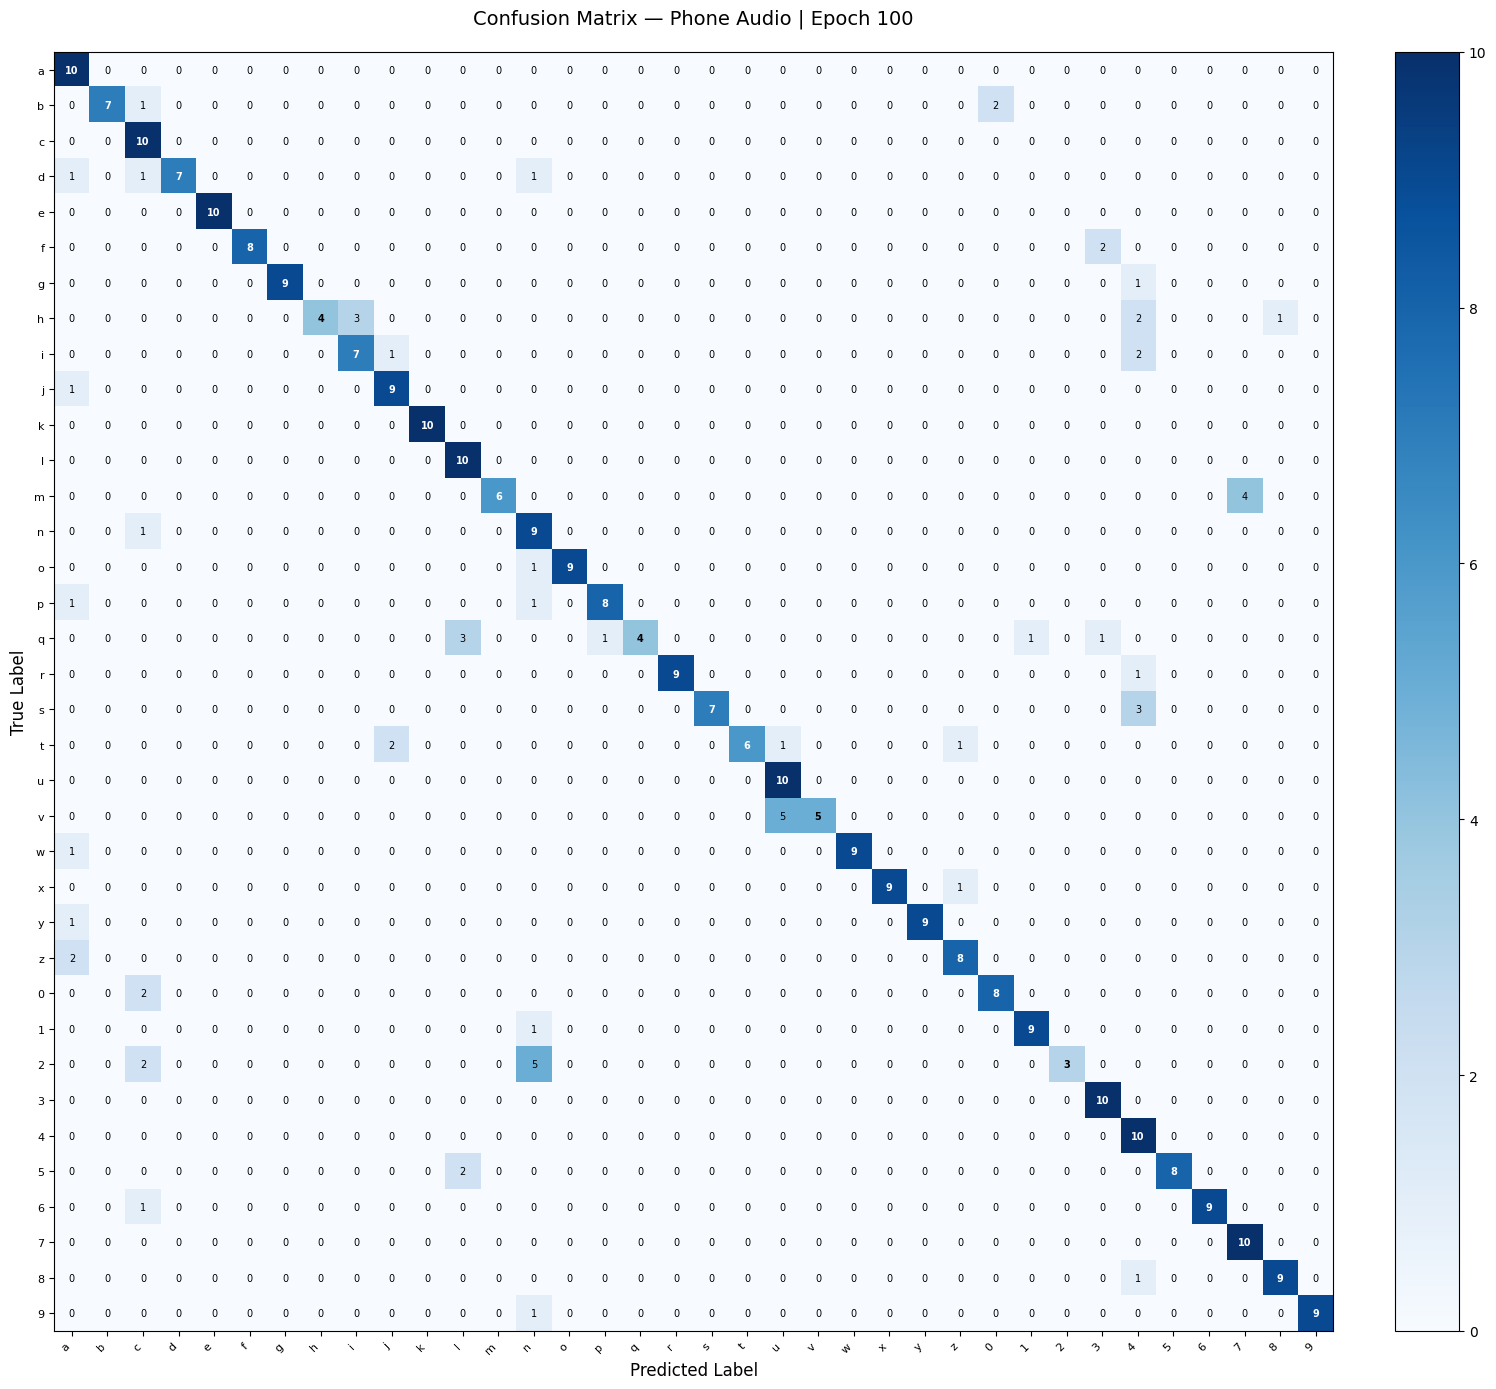

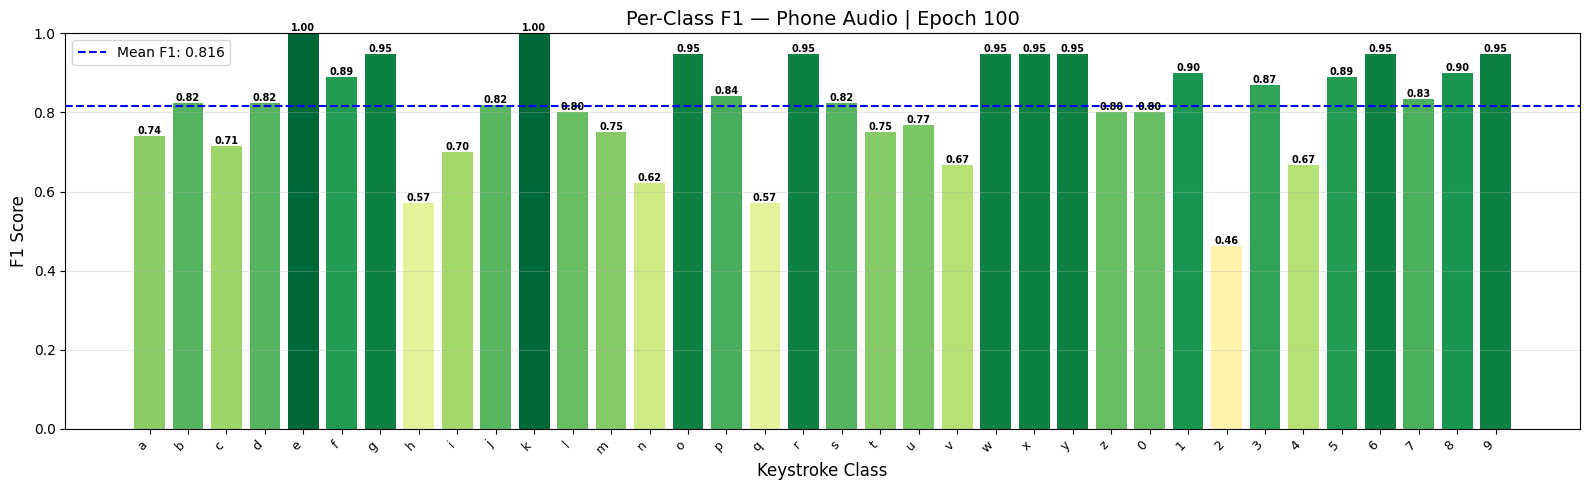

  ★ New best Weighted F1: 0.8159
  Time      : 11.97s
  Train     → Loss: 2.1298 | Acc: 0.4185
  Val       → Loss: 1.4316   | Acc: 0.8167
  Weighted  → P: 0.8787 | R: 0.8167 | F1: 0.8159

Epoch 101/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 101
  Accuracy  : 0.8250
  Precision : 0.8651  (weighted)
  Recall    : 0.8250  (weighted)
  F1 Score  : 0.8226  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6667     1.0000     0.8000         10
  b              1.0000     0.5000     0.6667         10
  c              0.6667     1.0000     0.8000         10
  d              1.0000     0.6000     0.7500         10
  e              0.9091     1.0000     0.9524         10
  f              0.8182     0.9000     0.8571         10
  g              0.9000     0.9000     0.9000         10
  h              1.0000     0.4000     0.5714         10
  i              0.5625     0.9000     0.6923         10
  j              1.0000     0.9000     0.9474         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     0.8000     0.8889         10
  m              0.


  Validation Results — Phone Audio | Epoch 102
  Accuracy  : 0.8472
  Precision : 0.8760  (weighted)
  Recall    : 0.8472  (weighted)
  F1 Score  : 0.8445  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8333     1.0000     0.9091         10
  b              1.0000     0.7000     0.8235         10
  c              0.8333     1.0000     0.9091         10
  d              0.8000     0.8000     0.8000         10
  e              0.9091     1.0000     0.9524         10
  f              0.8889     0.8000     0.8421         10
  g              0.8333     1.0000     0.9091         10
  h              1.0000     0.5000     0.6667         10
  i              0.5625     0.9000     0.6923         10
  j              1.0000     0.8000     0.8889         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     0.8000     0.8889         10
  m              1.


  Validation Results — Phone Audio | Epoch 103
  Accuracy  : 0.8250
  Precision : 0.8343  (weighted)
  Recall    : 0.8250  (weighted)
  F1 Score  : 0.8170  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9000     0.9474         10
  b              1.0000     0.7000     0.8235         10
  c              0.6667     1.0000     0.8000         10
  d              0.8889     0.8000     0.8421         10
  e              1.0000     1.0000     1.0000         10
  f              0.9000     0.9000     0.9000         10
  g              0.8889     0.8000     0.8421         10
  h              0.0000     0.0000     0.0000         10
  i              0.6667     1.0000     0.8000         10
  j              1.0000     0.9000     0.9474         10
  k              1.0000     0.9000     0.9474         10
  l              0.8889     0.8000     0.8421         10
  m              0.


  Validation Results — Phone Audio | Epoch 104
  Accuracy  : 0.7750
  Precision : 0.8475  (weighted)
  Recall    : 0.7750  (weighted)
  F1 Score  : 0.7685  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5263     1.0000     0.6897         10
  b              1.0000     0.1000     0.1818         10
  c              0.4762     1.0000     0.6452         10
  d              0.8750     0.7000     0.7778         10
  e              0.6667     1.0000     0.8000         10
  f              1.0000     0.7000     0.8235         10
  g              1.0000     1.0000     1.0000         10
  h              0.9000     0.9000     0.9000         10
  i              1.0000     0.8000     0.8889         10
  j              0.7273     0.8000     0.7619         10
  k              1.0000     1.0000     1.0000         10
  l              0.6667     1.0000     0.8000         10
  m              1.

...


  Validation Results — Phone Audio | Epoch 196
  Accuracy  : 0.9528
  Precision : 0.9602  (weighted)
  Recall    : 0.9528  (weighted)
  F1 Score  : 0.9524  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     0.9000     0.9474         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 197
  Accuracy  : 0.9639
  Precision : 0.9687  (weighted)
  Recall    : 0.9639  (weighted)
  F1 Score  : 0.9636  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 198
  Accuracy  : 0.9556
  Precision : 0.9593  (weighted)
  Recall    : 0.9556  (weighted)
  F1 Score  : 0.9549  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              0.9091     1.0000     0.9524         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              0.9091     1.0000     0.9524         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              0.


  Validation Results — Phone Audio | Epoch 199
  Accuracy  : 0.9611
  Precision : 0.9671  (weighted)
  Recall    : 0.9611  (weighted)
  F1 Score  : 0.9611  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     0.9000     0.9474         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     0.9000     0.9474         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 200
  Accuracy  : 0.9583
  Precision : 0.9636  (weighted)
  Recall    : 0.9583  (weighted)
  F1 Score  : 0.9578  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              0.9091     1.0000     0.9524         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              0.9091     1.0000     0.9524         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.

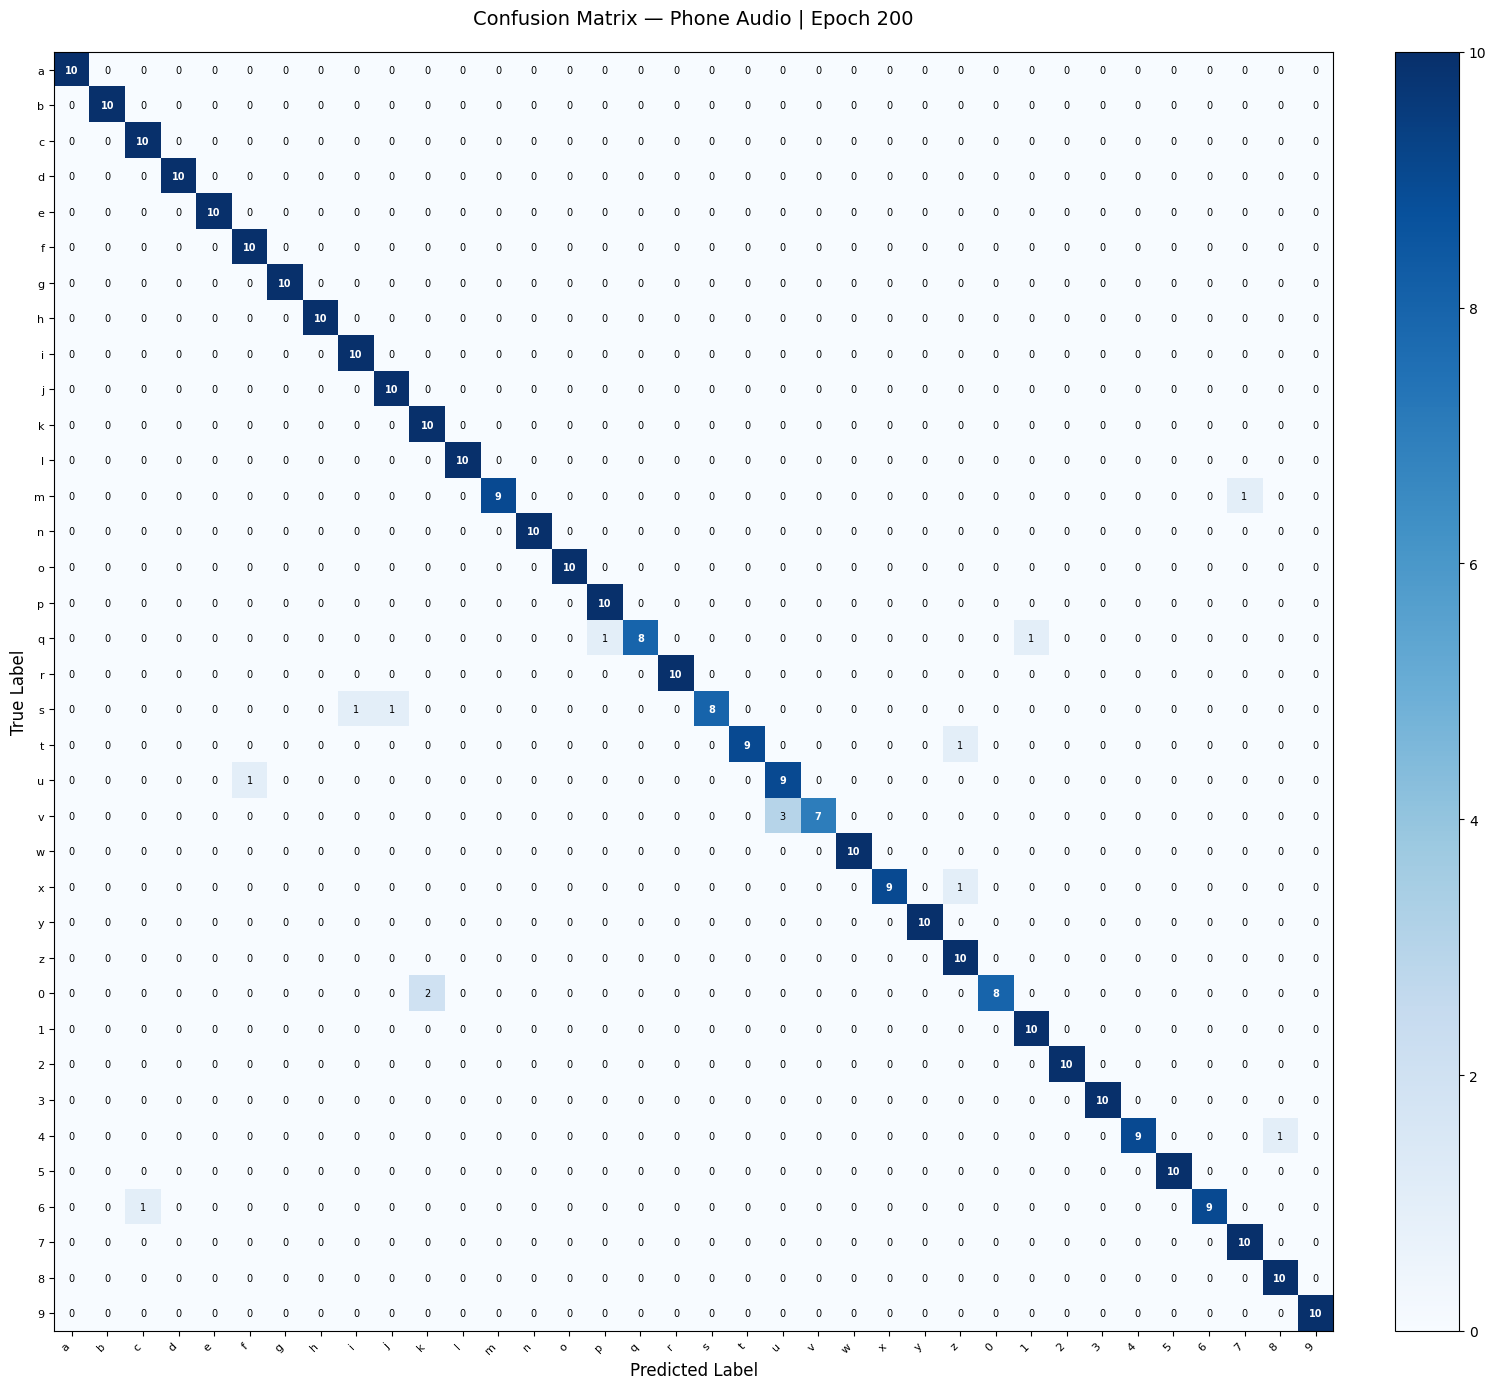

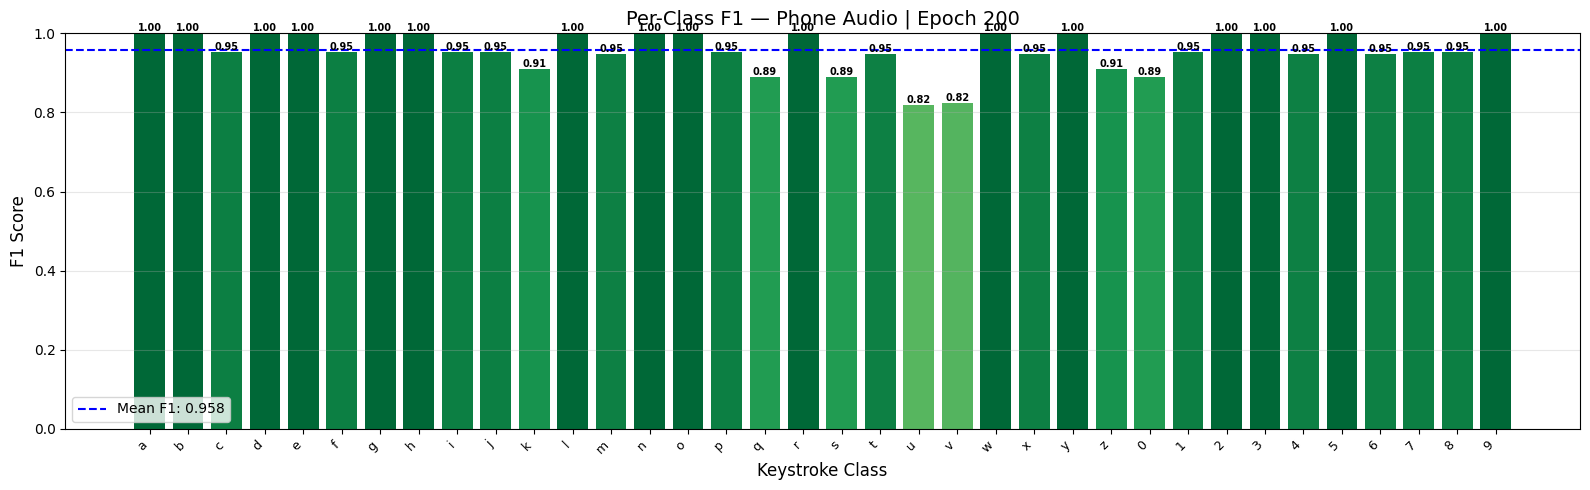

  Time      : 11.23s
  Train     → Loss: 1.5725 | Acc: 0.7315
  Val       → Loss: 0.9810   | Acc: 0.9583
  Weighted  → P: 0.9636 | R: 0.9583 | F1: 0.9578

Epoch 201/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 201
  Accuracy  : 0.9528
  Precision : 0.9608  (weighted)
  Recall    : 0.9528  (weighted)
  F1 Score  : 0.9527  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     0.8000     0.8889         10
  h              1.0000     1.0000     1.0000         10
  i              0.7692     1.0000     0.8696         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 202
  Accuracy  : 0.9583
  Precision : 0.9638  (weighted)
  Recall    : 0.9583  (weighted)
  F1 Score  : 0.9584  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     0.9000     0.9474         10
  h              1.0000     1.0000     1.0000         10
  i              0.8333     1.0000     0.9091         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     0.9000     0.9474         10
  m              1.


  Validation Results — Phone Audio | Epoch 203
  Accuracy  : 0.9417
  Precision : 0.9528  (weighted)
  Recall    : 0.9417  (weighted)
  F1 Score  : 0.9391  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     1.0000     1.0000         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              0.


  Validation Results — Phone Audio | Epoch 204
  Accuracy  : 0.9583
  Precision : 0.9625  (weighted)
  Recall    : 0.9583  (weighted)
  F1 Score  : 0.9580  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              0.9091     1.0000     0.9524         10
  i              0.9091     1.0000     0.9524         10
  j              0.9091     1.0000     0.9524         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.

...


  Validation Results — Phone Audio | Epoch 296
  Accuracy  : 0.9611
  Precision : 0.9656  (weighted)
  Recall    : 0.9611  (weighted)
  F1 Score  : 0.9611  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     0.9000     0.9474         10
  k              0.7143     1.0000     0.8333         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 297
  Accuracy  : 0.9611
  Precision : 0.9640  (weighted)
  Recall    : 0.9611  (weighted)
  F1 Score  : 0.9603  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.8333     1.0000     0.9091         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     0.9000     0.9474         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 298
  Accuracy  : 0.9722
  Precision : 0.9767  (weighted)
  Recall    : 0.9722  (weighted)
  F1 Score  : 0.9721  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     1.0000     1.0000         10
  k              0.7143     1.0000     0.8333         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 299
  Accuracy  : 0.9667
  Precision : 0.9701  (weighted)
  Recall    : 0.9667  (weighted)
  F1 Score  : 0.9664  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     1.0000     1.0000         10
  k              0.7692     1.0000     0.8696         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 300
  Accuracy  : 0.9667
  Precision : 0.9697  (weighted)
  Recall    : 0.9667  (weighted)
  F1 Score  : 0.9665  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              0.9091     1.0000     0.9524         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              1.

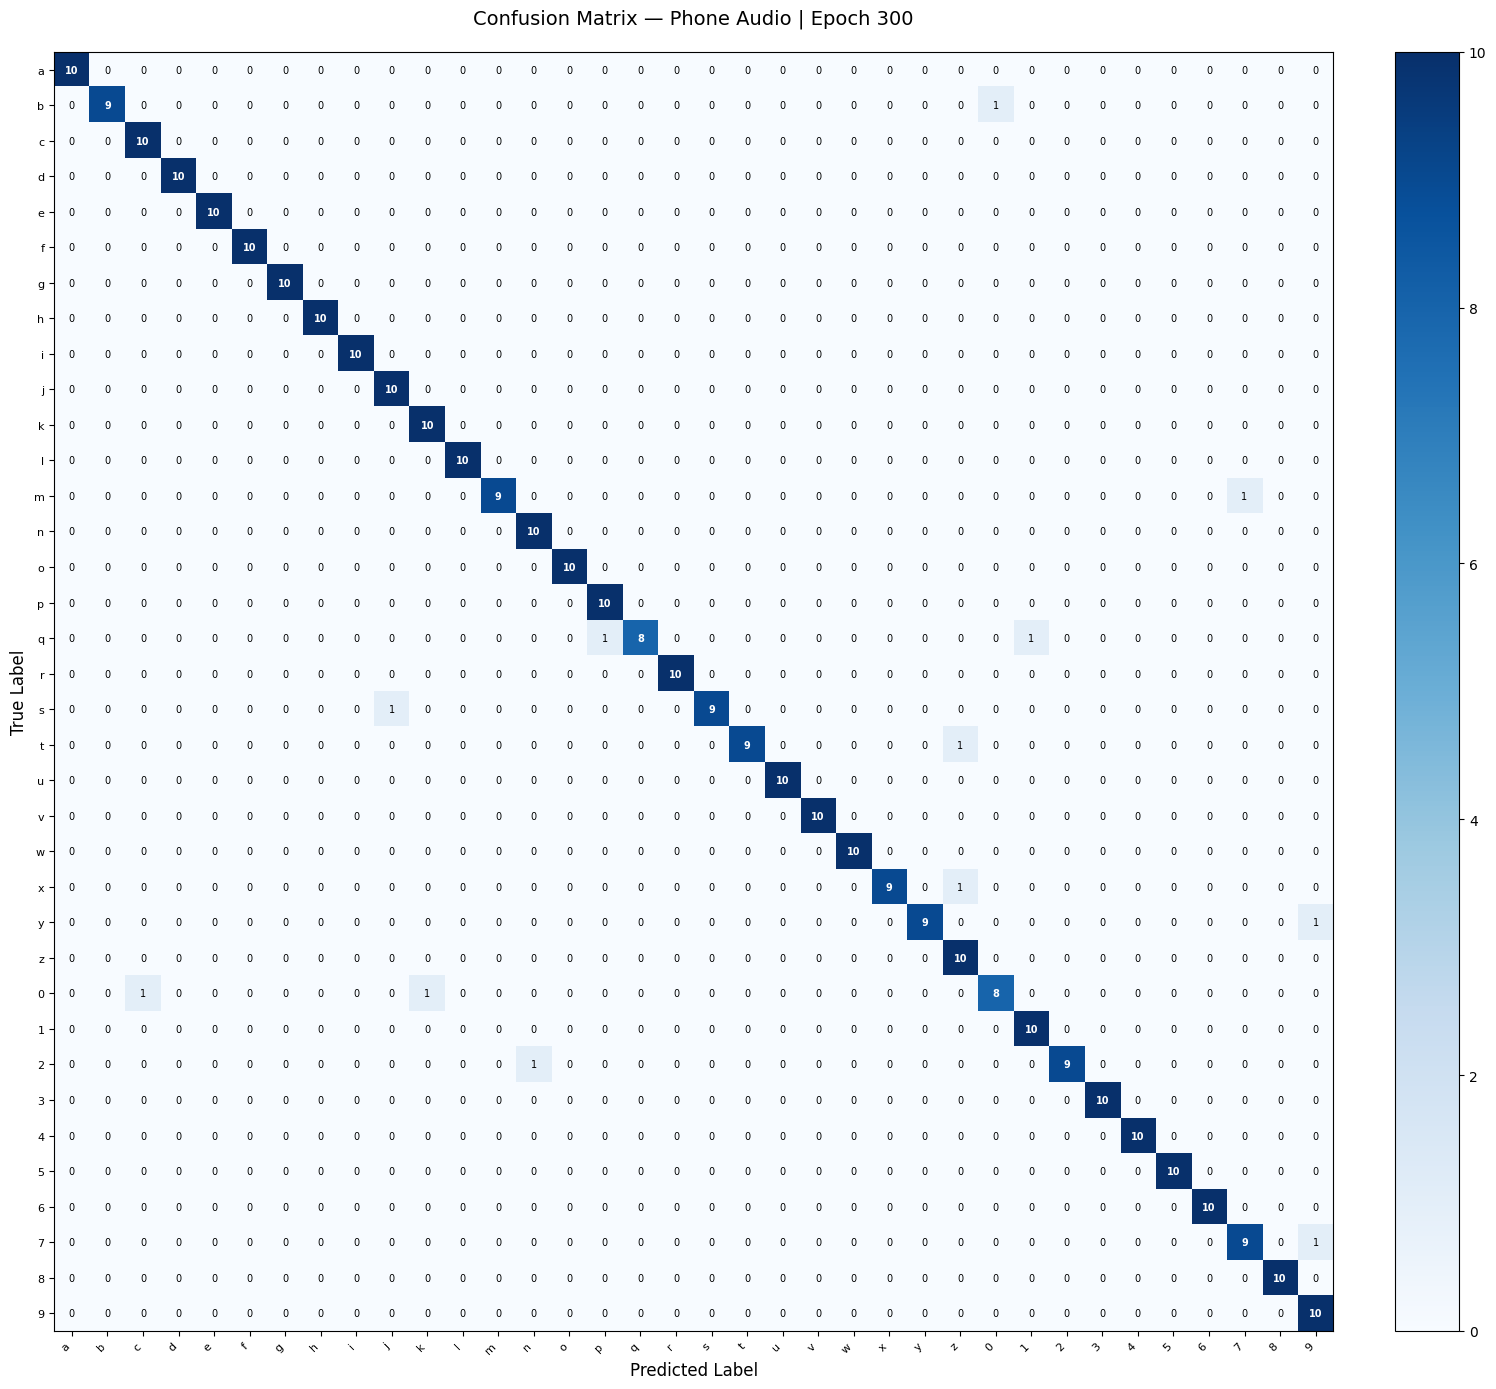

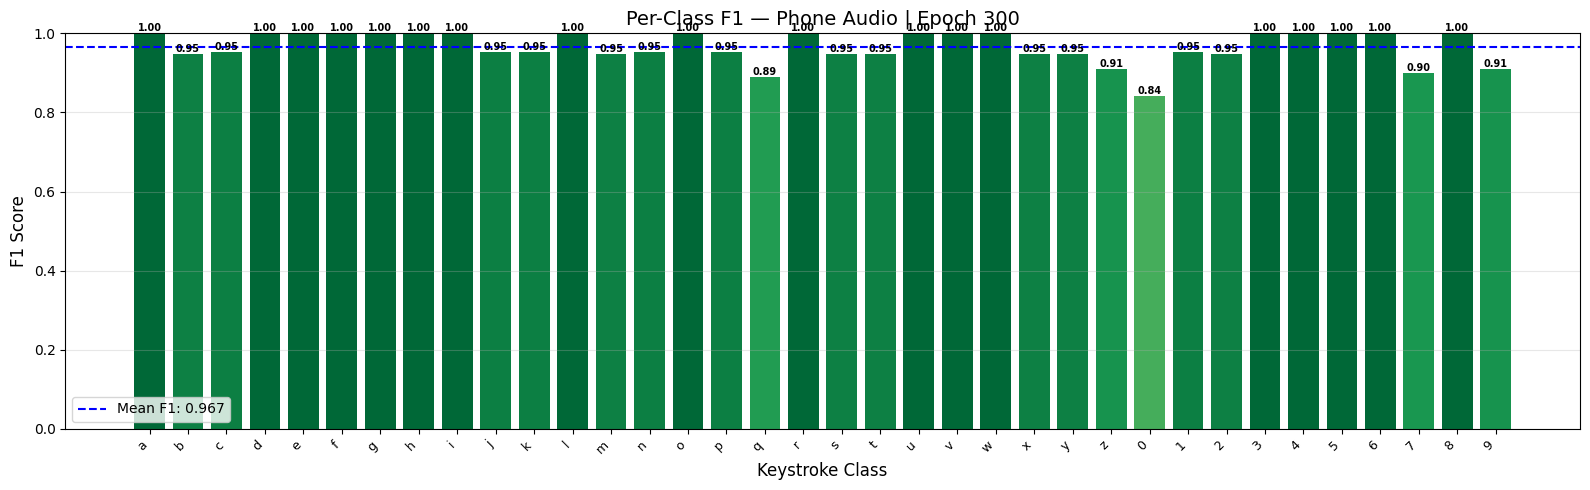

  Time      : 12.91s
  Train     → Loss: 1.5740 | Acc: 0.5574
  Val       → Loss: 0.9153   | Acc: 0.9667
  Weighted  → P: 0.9697 | R: 0.9667 | F1: 0.9665

Epoch 301/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 301
  Accuracy  : 0.9611
  Precision : 0.9661  (weighted)
  Recall    : 0.9611  (weighted)
  F1 Score  : 0.9611  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.7692     1.0000     0.8696         10
  d              1.0000     0.8000     0.8889         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 302
  Accuracy  : 0.9667
  Precision : 0.9691  (weighted)
  Recall    : 0.9667  (weighted)
  F1 Score  : 0.9664  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     0.9000     0.9474         10
  g              0.9091     1.0000     0.9524         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 303
  Accuracy  : 0.9639
  Precision : 0.9680  (weighted)
  Recall    : 0.9639  (weighted)
  F1 Score  : 0.9638  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     0.9000     0.9474         10
  g              0.9091     1.0000     0.9524         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.7692     1.0000     0.8696         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 304
  Accuracy  : 0.9750
  Precision : 0.9774  (weighted)
  Recall    : 0.9750  (weighted)
  F1 Score  : 0.9747  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.9091     1.0000     0.9524         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     1.0000     1.0000         10
  m              1.

...


  Validation Results — Phone Audio | Epoch 396
  Accuracy  : 0.9722
  Precision : 0.9746  (weighted)
  Recall    : 0.9722  (weighted)
  F1 Score  : 0.9720  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 397
  Accuracy  : 0.9778
  Precision : 0.9795  (weighted)
  Recall    : 0.9778  (weighted)
  F1 Score  : 0.9776  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.9091     1.0000     0.9524         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 398
  Accuracy  : 0.9722
  Precision : 0.9749  (weighted)
  Recall    : 0.9722  (weighted)
  F1 Score  : 0.9716  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.9091     1.0000     0.9524         10
  c              0.8333     1.0000     0.9091         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 399
  Accuracy  : 0.9722
  Precision : 0.9752  (weighted)
  Recall    : 0.9722  (weighted)
  F1 Score  : 0.9719  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 400
  Accuracy  : 0.9694
  Precision : 0.9721  (weighted)
  Recall    : 0.9694  (weighted)
  F1 Score  : 0.9690  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              1.

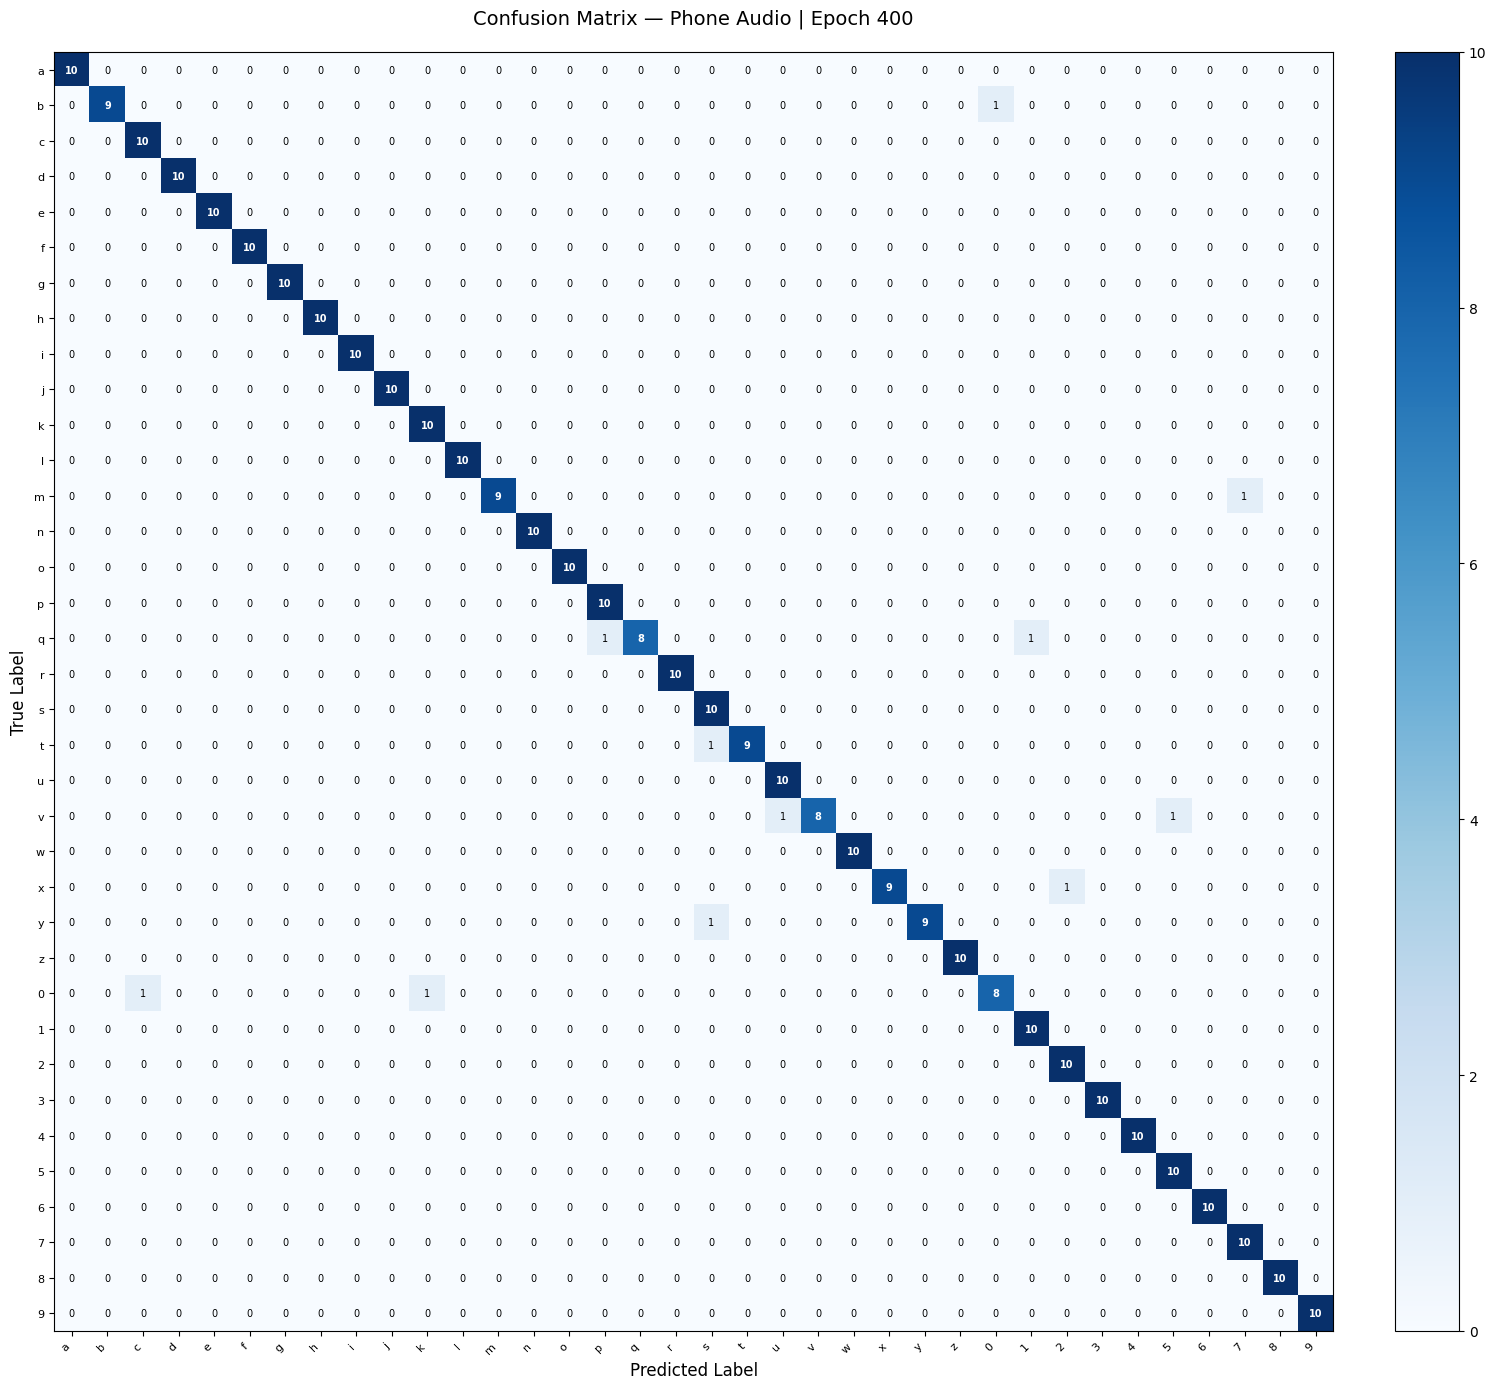

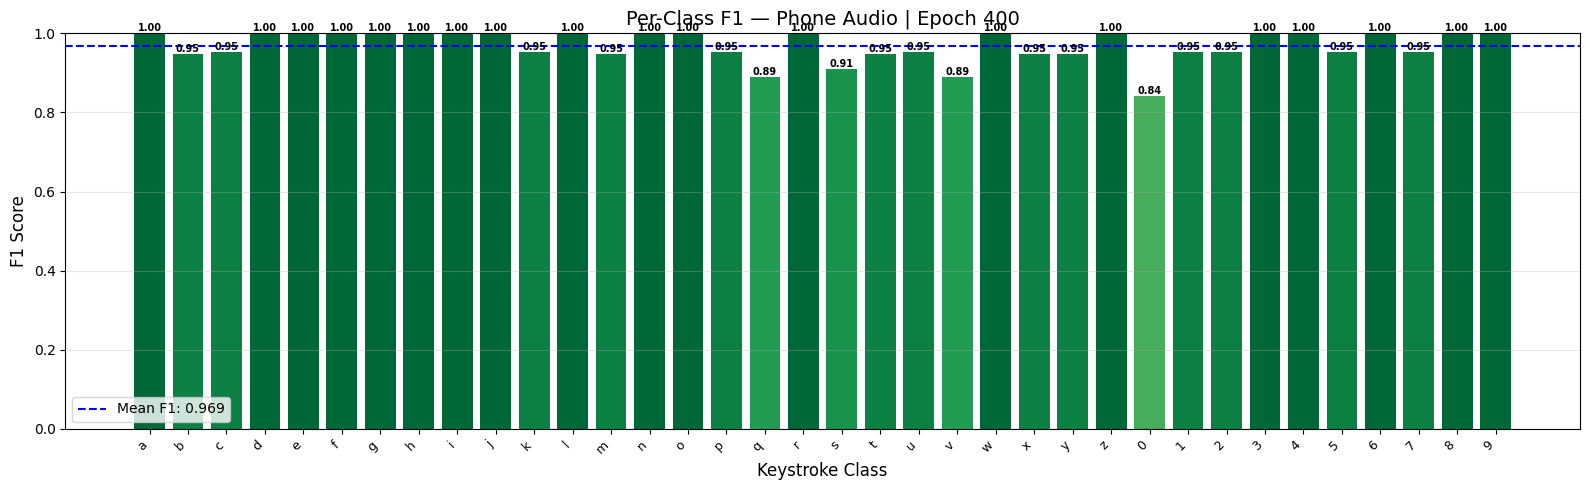

  Time      : 11.64s
  Train     → Loss: 1.3984 | Acc: 0.6963
  Val       → Loss: 0.8927   | Acc: 0.9694
  Weighted  → P: 0.9721 | R: 0.9694 | F1: 0.9690

Epoch 401/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 401
  Accuracy  : 0.9778
  Precision : 0.9801  (weighted)
  Recall    : 0.9778  (weighted)
  F1 Score  : 0.9777  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 402
  Accuracy  : 0.9750
  Precision : 0.9777  (weighted)
  Recall    : 0.9750  (weighted)
  F1 Score  : 0.9744  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.9091     1.0000     0.9524         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 403
  Accuracy  : 0.9750
  Precision : 0.9779  (weighted)
  Recall    : 0.9750  (weighted)
  F1 Score  : 0.9749  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 404
  Accuracy  : 0.9556
  Precision : 0.9620  (weighted)
  Recall    : 0.9556  (weighted)
  F1 Score  : 0.9553  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     1.0000     1.0000         10
  c              0.8333     1.0000     0.9091         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     0.9000     0.9474         10
  g              0.9091     1.0000     0.9524         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     0.9000     0.9474         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.

...


  Validation Results — Phone Audio | Epoch 496
  Accuracy  : 0.9778
  Precision : 0.9797  (weighted)
  Recall    : 0.9778  (weighted)
  F1 Score  : 0.9775  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 497
  Accuracy  : 0.9750
  Precision : 0.9772  (weighted)
  Recall    : 0.9750  (weighted)
  F1 Score  : 0.9747  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.8333     1.0000     0.9091         10
  c              1.0000     1.0000     1.0000         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 498
  Accuracy  : 0.9694
  Precision : 0.9725  (weighted)
  Recall    : 0.9694  (weighted)
  F1 Score  : 0.9686  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.8333     1.0000     0.9091         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 499
  Accuracy  : 0.9722
  Precision : 0.9758  (weighted)
  Recall    : 0.9722  (weighted)
  F1 Score  : 0.9722  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.8333     1.0000     0.9091         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 500
  Accuracy  : 0.9722
  Precision : 0.9750  (weighted)
  Recall    : 0.9722  (weighted)
  F1 Score  : 0.9719  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.7692     1.0000     0.8696         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              1.

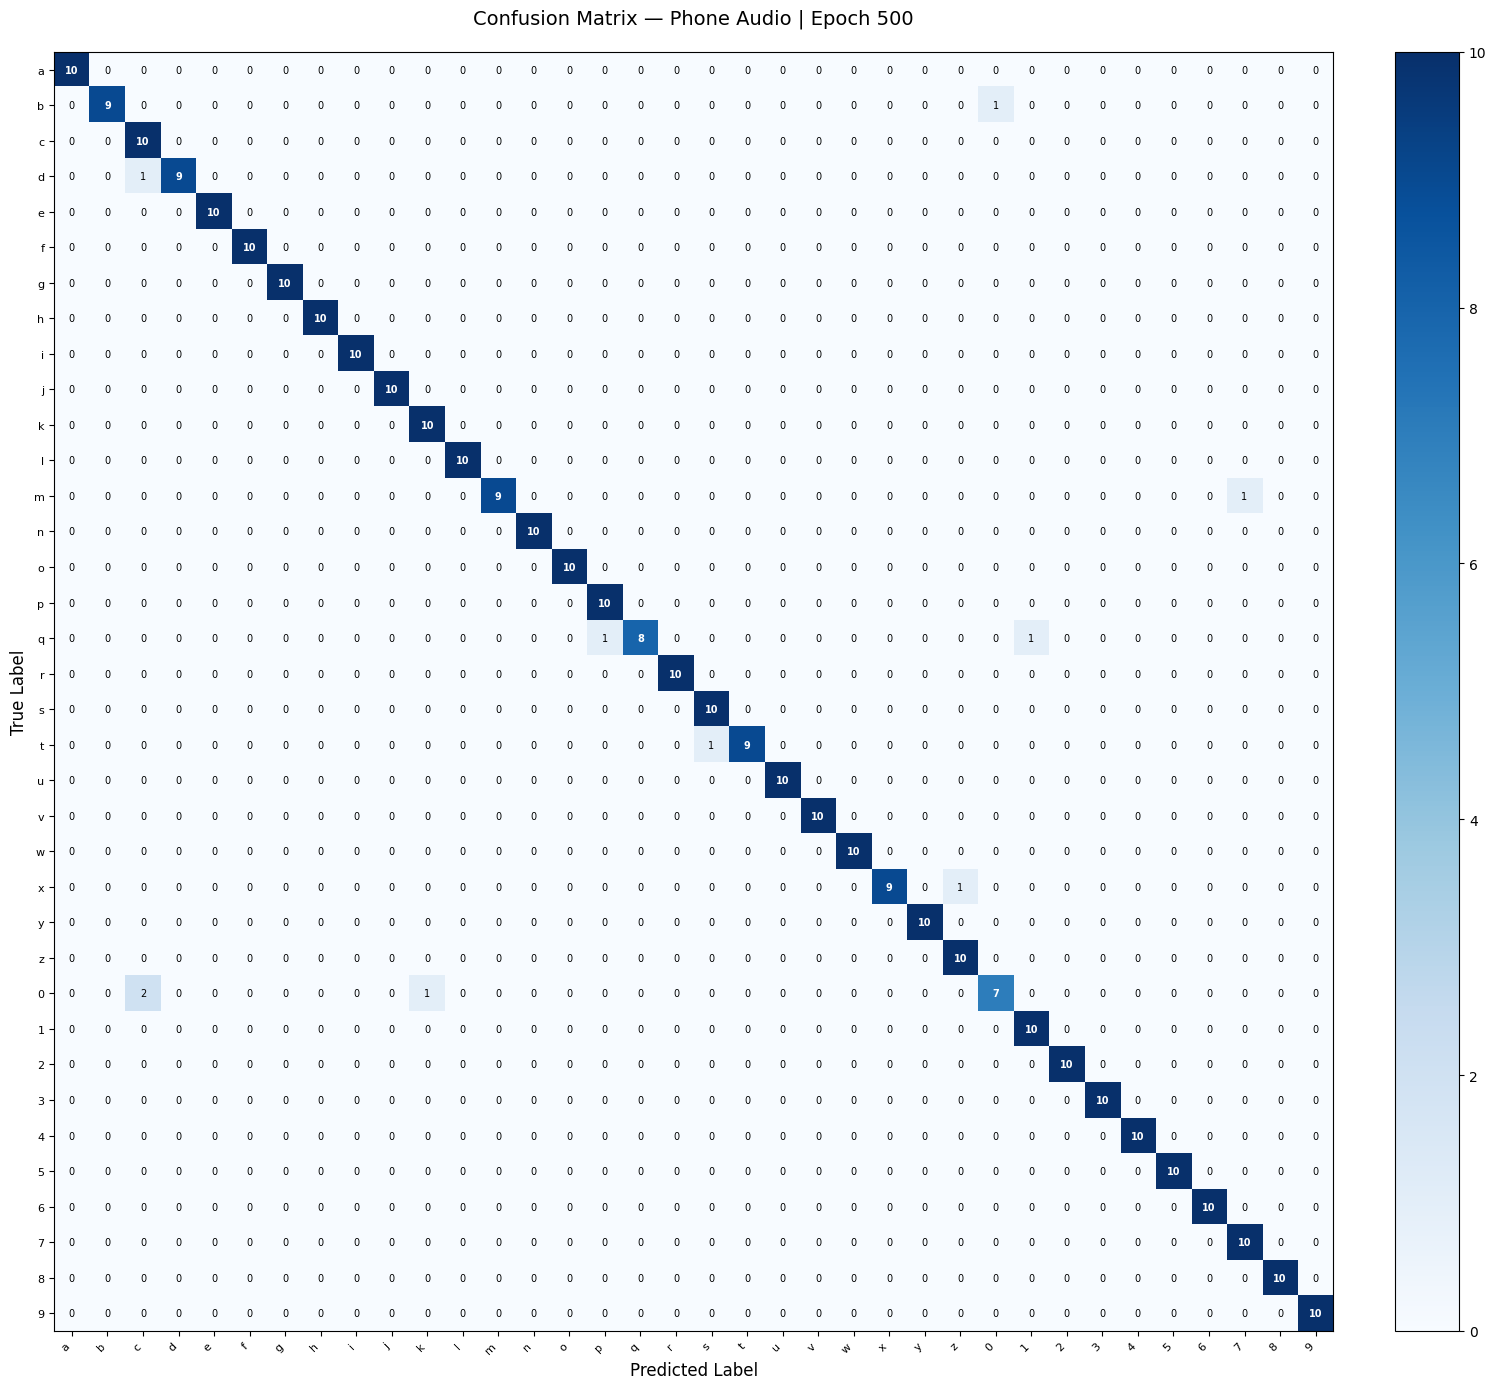

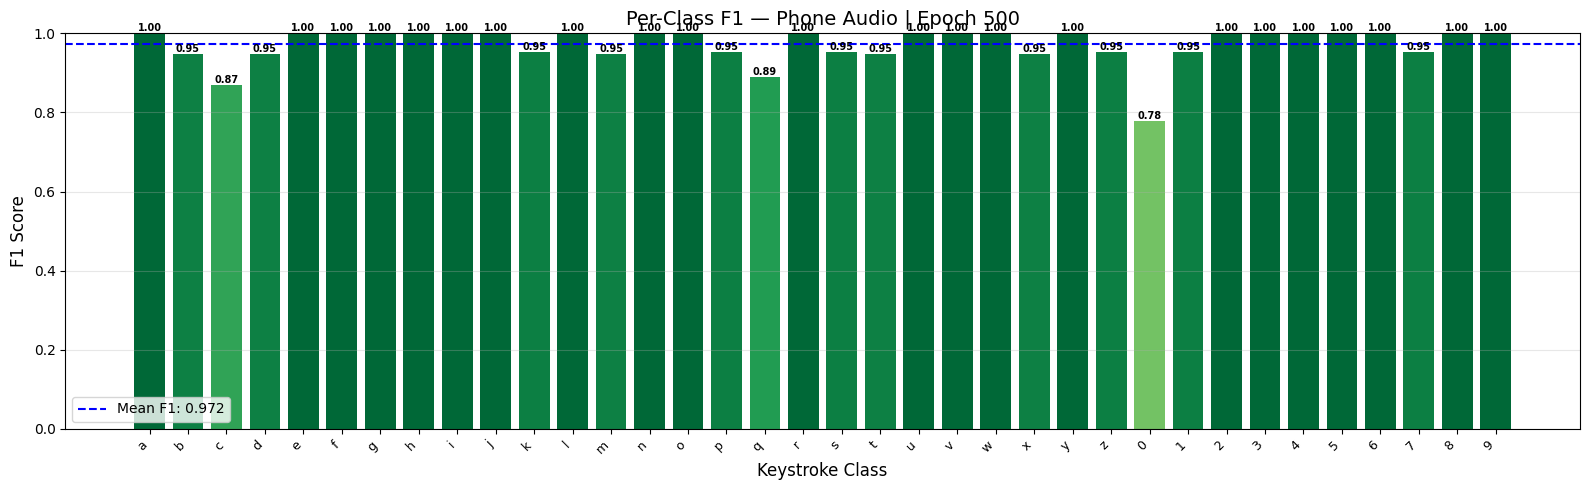

  Time      : 12.06s
  Train     → Loss: 1.3514 | Acc: 0.7481
  Val       → Loss: 0.8564   | Acc: 0.9722
  Weighted  → P: 0.9750 | R: 0.9722 | F1: 0.9719

Epoch 501/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 501
  Accuracy  : 0.9750
  Precision : 0.9781  (weighted)
  Recall    : 0.9750  (weighted)
  F1 Score  : 0.9749  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.9091     1.0000     0.9524         10
  c              0.8333     1.0000     0.9091         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 502
  Accuracy  : 0.9750
  Precision : 0.9785  (weighted)
  Recall    : 0.9750  (weighted)
  F1 Score  : 0.9750  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.8333     1.0000     0.9091         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     0.9000     0.9474         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     1.0000     1.0000         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 503
  Accuracy  : 0.9694
  Precision : 0.9720  (weighted)
  Recall    : 0.9694  (weighted)
  F1 Score  : 0.9687  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.9091     1.0000     0.9524         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              0.9091     1.0000     0.9524         10
  j              1.0000     1.0000     1.0000         10
  k              0.9091     1.0000     0.9524         10
  l              1.0000     1.0000     1.0000         10
  m              1.


  Validation Results — Phone Audio | Epoch 504
  Accuracy  : 0.9694
  Precision : 0.9725  (weighted)
  Recall    : 0.9694  (weighted)
  F1 Score  : 0.9689  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              1.0000     0.9000     0.9474         10
  c              0.9091     1.0000     0.9524         10
  d              1.0000     1.0000     1.0000         10
  e              1.0000     1.0000     1.0000         10
  f              1.0000     1.0000     1.0000         10
  g              1.0000     1.0000     1.0000         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              1.0000     1.0000     1.0000         10
  k              0.8333     1.0000     0.9091         10
  l              1.0000     1.0000     1.0000         10
  m              1.

...


  Validation Results — Zoom Audio | Epoch 96
  Accuracy  : 0.3000
  Precision : 0.2398  (weighted)
  Recall    : 0.3000  (weighted)
  F1 Score  : 0.2387  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.3889     0.7000     0.5000         10
  b              0.5714     0.4000     0.4706         10
  c              0.2727     0.3000     0.2857         10
  d              0.6667     0.4000     0.5000         10
  e              0.1724     0.5000     0.2564         10
  f              0.0000     0.0000     0.0000         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.7143     0.5000     0.5882         10
  k              0.7500     0.3000     0.4286         10
  l              0.0000     0.0000     0.0000         10
  m              0.12


  Validation Results — Zoom Audio | Epoch 97
  Accuracy  : 0.3167
  Precision : 0.2980  (weighted)
  Recall    : 0.3167  (weighted)
  F1 Score  : 0.2575  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.3636     0.8000     0.5000         10
  b              0.6667     0.4000     0.5000         10
  c              0.3846     0.5000     0.4348         10
  d              0.3000     0.6000     0.4000         10
  e              0.3333     0.3000     0.3158         10
  f              0.5000     0.1000     0.1667         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.5000     0.3000     0.3750         10
  k              0.5455     0.6000     0.5714         10
  l              0.0000     0.0000     0.0000         10
  m              0.00


  Validation Results — Zoom Audio | Epoch 98
  Accuracy  : 0.3167
  Precision : 0.3065  (weighted)
  Recall    : 0.3167  (weighted)
  F1 Score  : 0.2547  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4211     0.8000     0.5517         10
  b              0.4545     0.5000     0.4762         10
  c              0.4615     0.6000     0.5217         10
  d              0.1905     0.4000     0.2581         10
  e              0.1111     0.1000     0.1053         10
  f              1.0000     0.1000     0.1818         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.5714     0.4000     0.4706         10
  k              0.5556     0.5000     0.5263         10
  l              0.0000     0.0000     0.0000         10
  m              0.00


  Validation Results — Zoom Audio | Epoch 99
  Accuracy  : 0.3194
  Precision : 0.2974  (weighted)
  Recall    : 0.3194  (weighted)
  F1 Score  : 0.2628  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6667     0.6000     0.6316         10
  b              0.6250     0.5000     0.5556         10
  c              0.2222     0.2000     0.2105         10
  d              0.5000     0.4000     0.4444         10
  e              0.0909     0.1000     0.0952         10
  f              0.0000     0.0000     0.0000         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.5333     0.8000     0.6400         10
  k              0.7500     0.3000     0.4286         10
  l              0.0000     0.0000     0.0000         10
  m              0.25


  Validation Results — Zoom Audio | Epoch 100
  Accuracy  : 0.3250
  Precision : 0.2776  (weighted)
  Recall    : 0.3250  (weighted)
  F1 Score  : 0.2662  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.7143     0.5000     0.5882         10
  b              0.5000     0.1000     0.1667         10
  c              0.2941     0.5000     0.3704         10
  d              0.7000     0.7000     0.7000         10
  e              0.0833     0.1000     0.0909         10
  f              0.4286     0.3000     0.3529         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.5556     1.0000     0.7143         10
  k              0.6364     0.7000     0.6667         10
  l              0.0000     0.0000     0.0000         10
  m              0.0

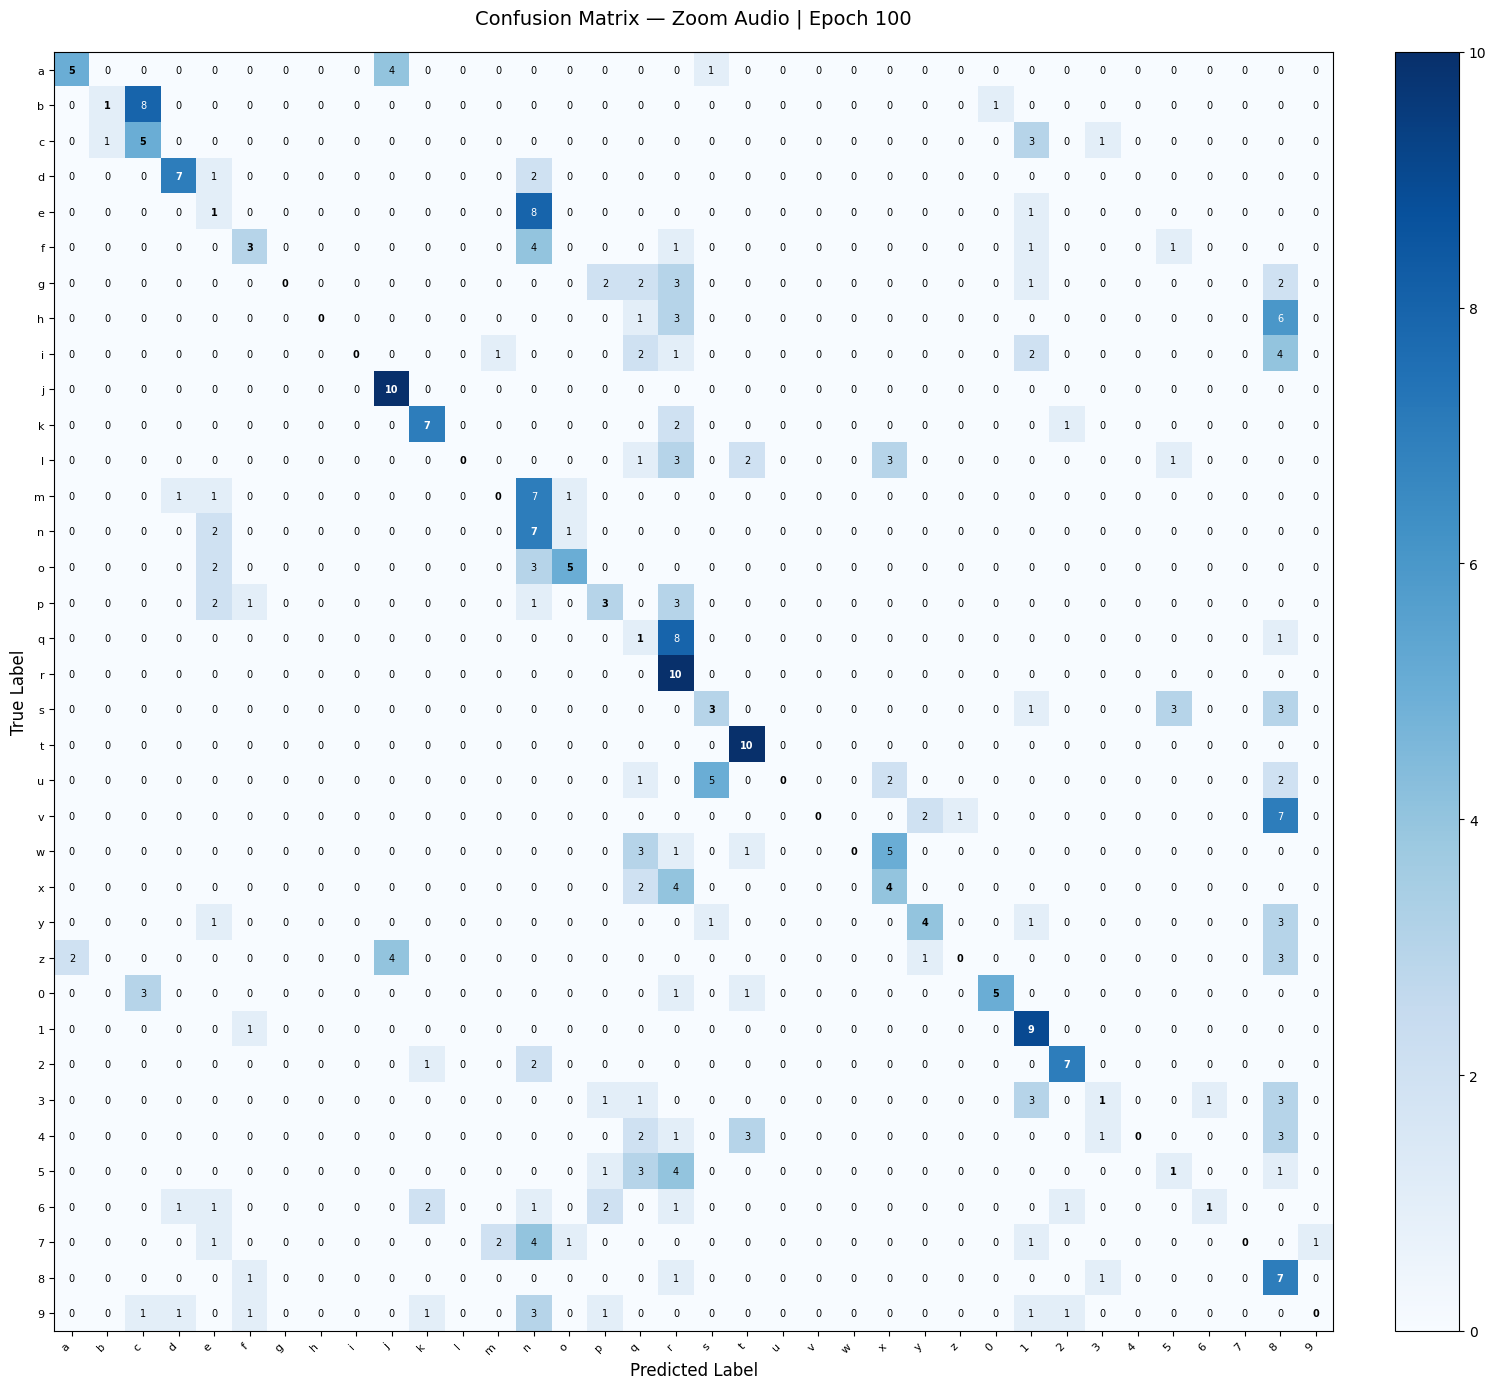

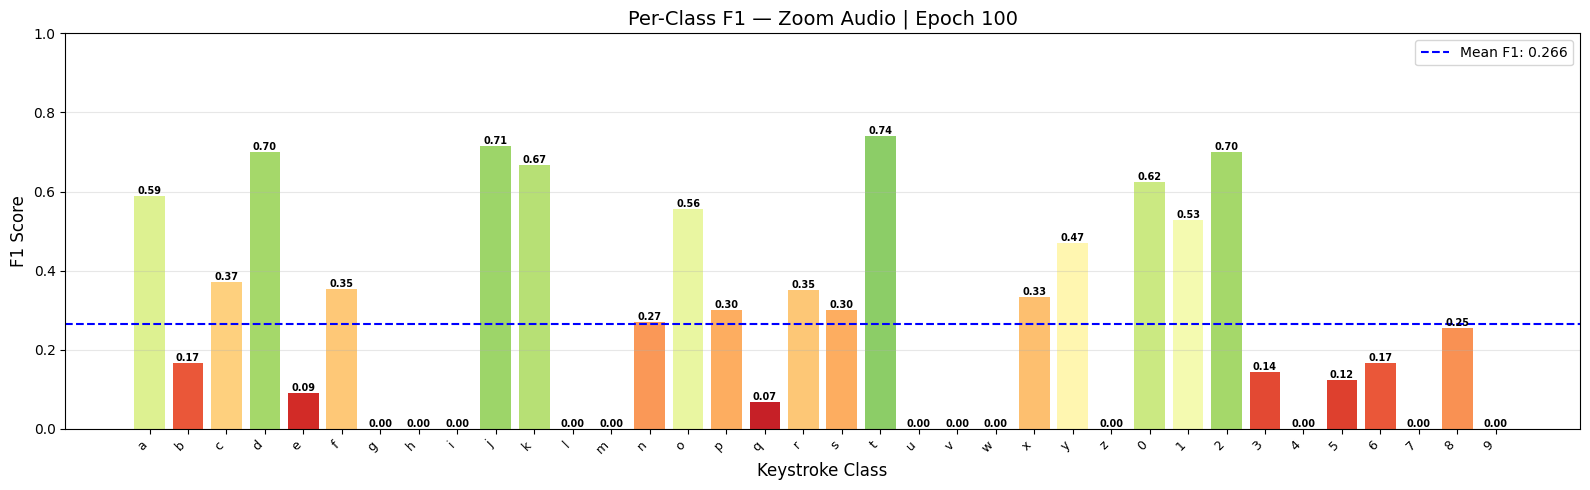

  Time      : 12.40s
  Train     → Loss: 2.7060 | Acc: 0.2352
  Val       → Loss: 2.4594   | Acc: 0.3250
  Weighted  → P: 0.2776 | R: 0.3250 | F1: 0.2662

Epoch 101/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 101
  Accuracy  : 0.4028
  Precision : 0.4235  (weighted)
  Recall    : 0.4028  (weighted)
  F1 Score  : 0.3514  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4286     0.6000     0.5000         10
  b              0.6667     0.4000     0.5000         10
  c              0.4118     0.7000     0.5185         10
  d              0.5833     0.7000     0.6364         10
  e              0.2424     0.8000     0.3721         10
  f              0.6667     0.2000     0.3077         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.4211     0.8000     0.5517         10
  k              0.8333     0.5000     0.6250         10
  l              0.5000     0.1000     0.1667         10
  m              0.0


  Validation Results — Zoom Audio | Epoch 102
  Accuracy  : 0.2806
  Precision : 0.2378  (weighted)
  Recall    : 0.2806  (weighted)
  F1 Score  : 0.2132  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6667     0.4000     0.5000         10
  b              0.5714     0.4000     0.4706         10
  c              0.4000     0.6000     0.4800         10
  d              0.2381     0.5000     0.3226         10
  e              0.1429     0.1000     0.1176         10
  f              0.0909     0.1000     0.0952         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.4348     1.0000     0.6061         10
  k              0.5000     0.3000     0.3750         10
  l              0.0000     0.0000     0.0000         10
  m              0.0


  Validation Results — Zoom Audio | Epoch 103
  Accuracy  : 0.3611
  Precision : 0.2828  (weighted)
  Recall    : 0.3611  (weighted)
  F1 Score  : 0.2950  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.7500     0.3000     0.4286         10
  b              0.5000     0.4000     0.4444         10
  c              0.4444     0.4000     0.4211         10
  d              0.5000     0.5000     0.5000         10
  e              0.4000     0.6000     0.4800         10
  f              0.5455     0.6000     0.5714         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.5000     0.9000     0.6429         10
  k              0.5833     0.7000     0.6364         10
  l              0.0000     0.0000     0.0000         10
  m              0.2


  Validation Results — Zoom Audio | Epoch 104
  Accuracy  : 0.3000
  Precision : 0.2142  (weighted)
  Recall    : 0.3000  (weighted)
  F1 Score  : 0.2299  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.7143     0.5000     0.5882         10
  b              0.6667     0.4000     0.5000         10
  c              0.4444     0.8000     0.5714         10
  d              0.2424     0.8000     0.3721         10
  e              0.0667     0.1000     0.0800         10
  f              0.3750     0.3000     0.3333         10
  g              0.0000     0.0000     0.0000         10
  h              0.0000     0.0000     0.0000         10
  i              0.0000     0.0000     0.0000         10
  j              0.5000     0.8000     0.6154         10
  k              0.6364     0.7000     0.6667         10
  l              0.0000     0.0000     0.0000         10
  m              0.0

...


  Validation Results — Zoom Audio | Epoch 196
  Accuracy  : 0.8056
  Precision : 0.8310  (weighted)
  Recall    : 0.8056  (weighted)
  F1 Score  : 0.8007  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9000     0.9000     0.9000         10
  b              1.0000     0.9000     0.9474         10
  c              0.9000     0.9000     0.9000         10
  d              1.0000     0.9000     0.9474         10
  e              0.6667     0.4000     0.5000         10
  f              1.0000     0.8000     0.8889         10
  g              1.0000     0.3000     0.4615         10
  h              0.4762     1.0000     0.6452         10
  i              0.8333     0.5000     0.6250         10
  j              0.9000     0.9000     0.9000         10
  k              0.9000     0.9000     0.9000         10
  l              0.8333     0.5000     0.6250         10
  m              0.5


  Validation Results — Zoom Audio | Epoch 197
  Accuracy  : 0.7306
  Precision : 0.7768  (weighted)
  Recall    : 0.7306  (weighted)
  F1 Score  : 0.7144  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.5000     0.6667         10
  b              0.7692     1.0000     0.8696         10
  c              0.8889     0.8000     0.8421         10
  d              0.6250     1.0000     0.7692         10
  e              1.0000     0.3000     0.4615         10
  f              0.4500     0.9000     0.6000         10
  g              0.7500     0.3000     0.4286         10
  h              0.8000     0.8000     0.8000         10
  i              1.0000     0.3000     0.4615         10
  j              0.7000     0.7000     0.7000         10
  k              0.6429     0.9000     0.7500         10
  l              0.5714     0.4000     0.4706         10
  m              0.4


  Validation Results — Zoom Audio | Epoch 198
  Accuracy  : 0.8333
  Precision : 0.8580  (weighted)
  Recall    : 0.8333  (weighted)
  F1 Score  : 0.8315  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.6000     0.7500         10
  b              0.9000     0.9000     0.9000         10
  c              0.8889     0.8000     0.8421         10
  d              0.9000     0.9000     0.9000         10
  e              0.6667     0.6000     0.6316         10
  f              0.7273     0.8000     0.7619         10
  g              1.0000     0.7000     0.8235         10
  h              0.5294     0.9000     0.6667         10
  i              1.0000     0.4000     0.5714         10
  j              0.7143     1.0000     0.8333         10
  k              1.0000     0.8000     0.8889         10
  l              0.8571     0.6000     0.7059         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 199
  Accuracy  : 0.8417
  Precision : 0.8594  (weighted)
  Recall    : 0.8417  (weighted)
  F1 Score  : 0.8368  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.8333     1.0000     0.9091         10
  c              0.8889     0.8000     0.8421         10
  d              0.9000     0.9000     0.9000         10
  e              0.8000     0.4000     0.5333         10
  f              0.8182     0.9000     0.8571         10
  g              1.0000     0.6000     0.7500         10
  h              0.7500     0.9000     0.8182         10
  i              0.8750     0.7000     0.7778         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.8000     0.8889         10
  l              0.8000     0.4000     0.5333         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 200
  Accuracy  : 0.8250
  Precision : 0.8565  (weighted)
  Recall    : 0.8250  (weighted)
  F1 Score  : 0.8209  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.7000     0.8235         10
  b              0.8333     1.0000     0.9091         10
  c              1.0000     0.8000     0.8889         10
  d              0.9000     0.9000     0.9000         10
  e              0.6429     0.9000     0.7500         10
  f              0.8750     0.7000     0.7778         10
  g              0.8182     0.9000     0.8571         10
  h              0.7273     0.8000     0.7619         10
  i              1.0000     0.6000     0.7500         10
  j              0.7143     1.0000     0.8333         10
  k              1.0000     0.8000     0.8889         10
  l              0.7143     0.5000     0.5882         10
  m              0.5

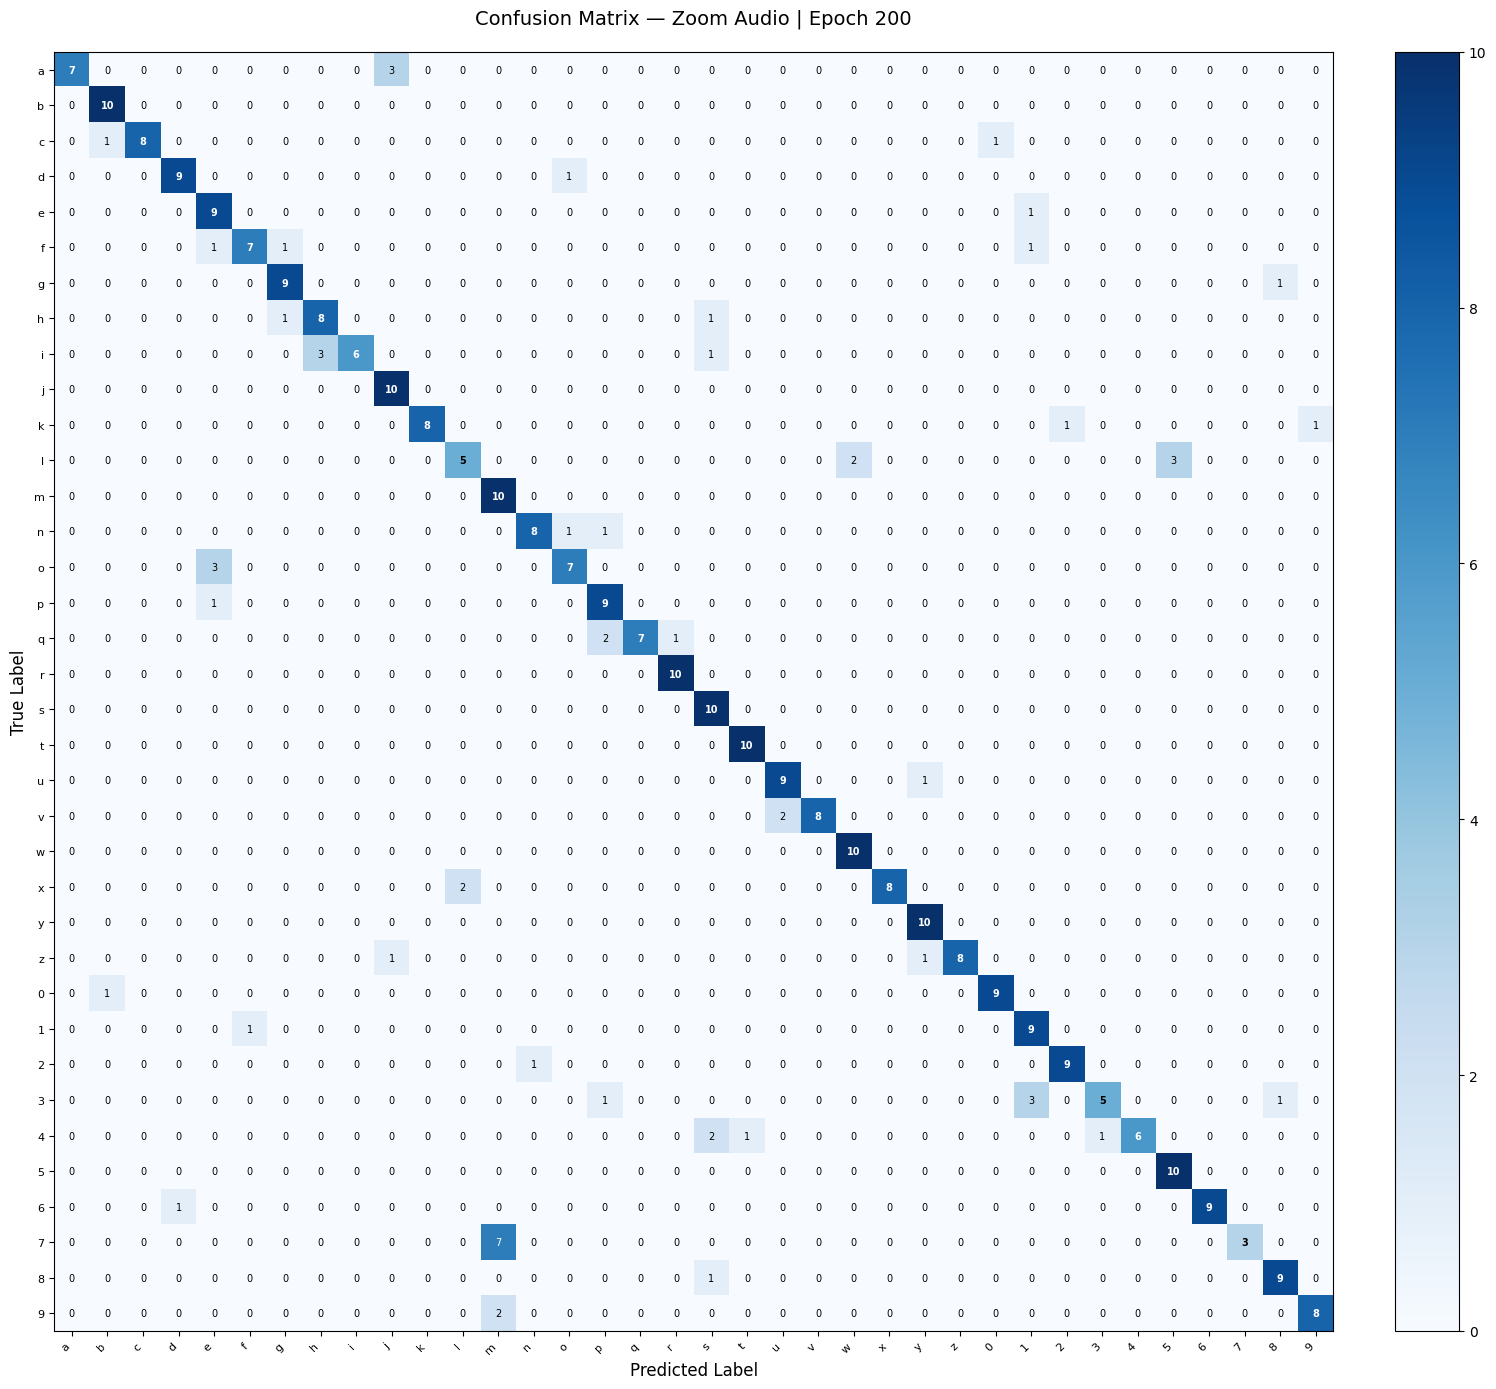

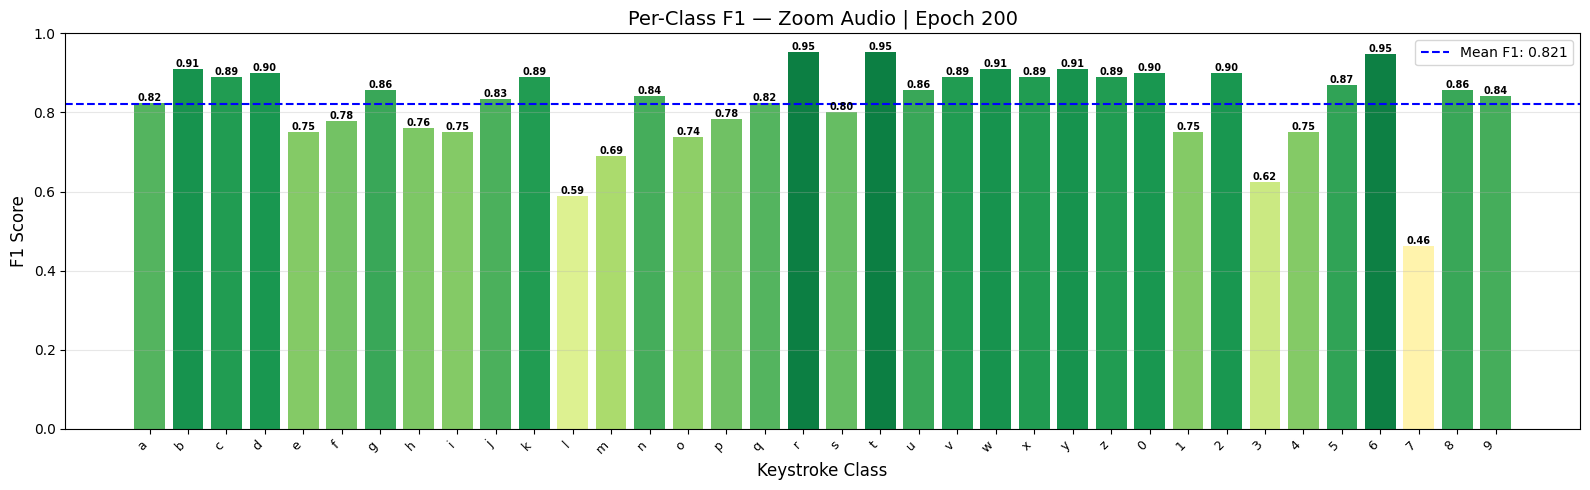

  Time      : 12.41s
  Train     → Loss: 1.8512 | Acc: 0.5259
  Val       → Loss: 1.3937   | Acc: 0.8250
  Weighted  → P: 0.8565 | R: 0.8250 | F1: 0.8209

Epoch 201/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 201
  Accuracy  : 0.8222
  Precision : 0.8453  (weighted)
  Recall    : 0.8222  (weighted)
  F1 Score  : 0.8176  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8750     0.7000     0.7778         10
  b              1.0000     0.9000     0.9474         10
  c              0.9000     0.9000     0.9000         10
  d              1.0000     0.9000     0.9474         10
  e              0.8750     0.7000     0.7778         10
  f              0.7500     0.9000     0.8182         10
  g              1.0000     0.4000     0.5714         10
  h              0.6000     0.9000     0.7200         10
  i              1.0000     0.5000     0.6667         10
  j              0.9091     1.0000     0.9524         10
  k              0.8182     0.9000     0.8571         10
  l              0.7143     0.5000     0.5882         10
  m              0.5


  Validation Results — Zoom Audio | Epoch 202
  Accuracy  : 0.8278
  Precision : 0.8515  (weighted)
  Recall    : 0.8278  (weighted)
  F1 Score  : 0.8235  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8000     0.8000     0.8000         10
  b              1.0000     0.9000     0.9474         10
  c              0.9000     0.9000     0.9000         10
  d              1.0000     0.9000     0.9474         10
  e              0.8000     0.4000     0.5333         10
  f              1.0000     0.7000     0.8235         10
  g              0.8000     0.4000     0.5333         10
  h              0.5882     1.0000     0.7407         10
  i              1.0000     0.6000     0.7500         10
  j              1.0000     0.9000     0.9474         10
  k              0.8000     0.8000     0.8000         10
  l              0.8000     0.4000     0.5333         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 203
  Accuracy  : 0.7972
  Precision : 0.8047  (weighted)
  Recall    : 0.7972  (weighted)
  F1 Score  : 0.7847  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8889     0.8000     0.8421         10
  b              0.8333     1.0000     0.9091         10
  c              1.0000     0.8000     0.8889         10
  d              0.5000     0.9000     0.6429         10
  e              0.6000     0.3000     0.4000         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.4000     0.5714         10
  h              0.5625     0.9000     0.6923         10
  i              0.8571     0.6000     0.7059         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     0.9000     0.9474         10
  l              0.8571     0.6000     0.7059         10
  m              0.5


  Validation Results — Zoom Audio | Epoch 204
  Accuracy  : 0.8056
  Precision : 0.8289  (weighted)
  Recall    : 0.8056  (weighted)
  F1 Score  : 0.7981  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.7500     0.9000     0.8182         10
  b              0.9091     1.0000     0.9524         10
  c              1.0000     0.8000     0.8889         10
  d              1.0000     0.9000     0.9474         10
  e              0.6667     0.4000     0.5000         10
  f              1.0000     0.5000     0.6667         10
  g              0.6000     0.3000     0.4000         10
  h              0.5263     1.0000     0.6897         10
  i              0.7500     0.6000     0.6667         10
  j              1.0000     0.7000     0.8235         10
  k              0.8182     0.9000     0.8571         10
  l              1.0000     0.4000     0.5714         10
  m              0.6

...


  Validation Results — Zoom Audio | Epoch 296
  Accuracy  : 0.8944
  Precision : 0.9080  (weighted)
  Recall    : 0.8944  (weighted)
  F1 Score  : 0.8924  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9000     0.9474         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     0.9000     0.9474         10
  d              1.0000     1.0000     1.0000         10
  e              0.9000     0.9000     0.9000         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.7000     0.8235         10
  h              0.7143     1.0000     0.8333         10
  i              0.8889     0.8000     0.8421         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     0.5000     0.6667         10
  l              0.8571     0.6000     0.7059         10
  m              0.8


  Validation Results — Zoom Audio | Epoch 297
  Accuracy  : 0.8694
  Precision : 0.8837  (weighted)
  Recall    : 0.8694  (weighted)
  F1 Score  : 0.8666  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.7000     0.8235         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     0.9000     0.9474         10
  d              0.8182     0.9000     0.8571         10
  e              0.7273     0.8000     0.7619         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.7000     0.8235         10
  h              0.7692     1.0000     0.8696         10
  i              0.9000     0.9000     0.9000         10
  j              0.7692     1.0000     0.8696         10
  k              1.0000     0.5000     0.6667         10
  l              0.8571     0.6000     0.7059         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 298
  Accuracy  : 0.8667
  Precision : 0.8796  (weighted)
  Recall    : 0.8667  (weighted)
  F1 Score  : 0.8608  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.6000     0.7500         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.8333     1.0000     0.9091         10
  e              0.8571     0.6000     0.7059         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.7000     0.8235         10
  h              0.9091     1.0000     0.9524         10
  i              0.8333     1.0000     0.9091         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.8000     0.8889         10
  l              0.7500     0.6000     0.6667         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 299
  Accuracy  : 0.8750
  Precision : 0.8837  (weighted)
  Recall    : 0.8750  (weighted)
  F1 Score  : 0.8725  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.7692     1.0000     0.8696         10
  c              0.8750     0.7000     0.7778         10
  d              0.9091     1.0000     0.9524         10
  e              0.8750     0.7000     0.7778         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.8000     0.8889         10
  h              1.0000     0.9000     0.9474         10
  i              0.8182     0.9000     0.8571         10
  j              0.9091     1.0000     0.9524         10
  k              1.0000     0.7000     0.8235         10
  l              0.8571     0.6000     0.7059         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 300
  Accuracy  : 0.8833
  Precision : 0.8946  (weighted)
  Recall    : 0.8833  (weighted)
  F1 Score  : 0.8812  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.8333     1.0000     0.9091         10
  e              0.8889     0.8000     0.8421         10
  f              1.0000     0.8000     0.8889         10
  g              1.0000     0.8000     0.8889         10
  h              0.9091     1.0000     0.9524         10
  i              1.0000     0.9000     0.9474         10
  j              0.9091     1.0000     0.9524         10
  k              1.0000     0.7000     0.8235         10
  l              0.8571     0.6000     0.7059         10
  m              0.8

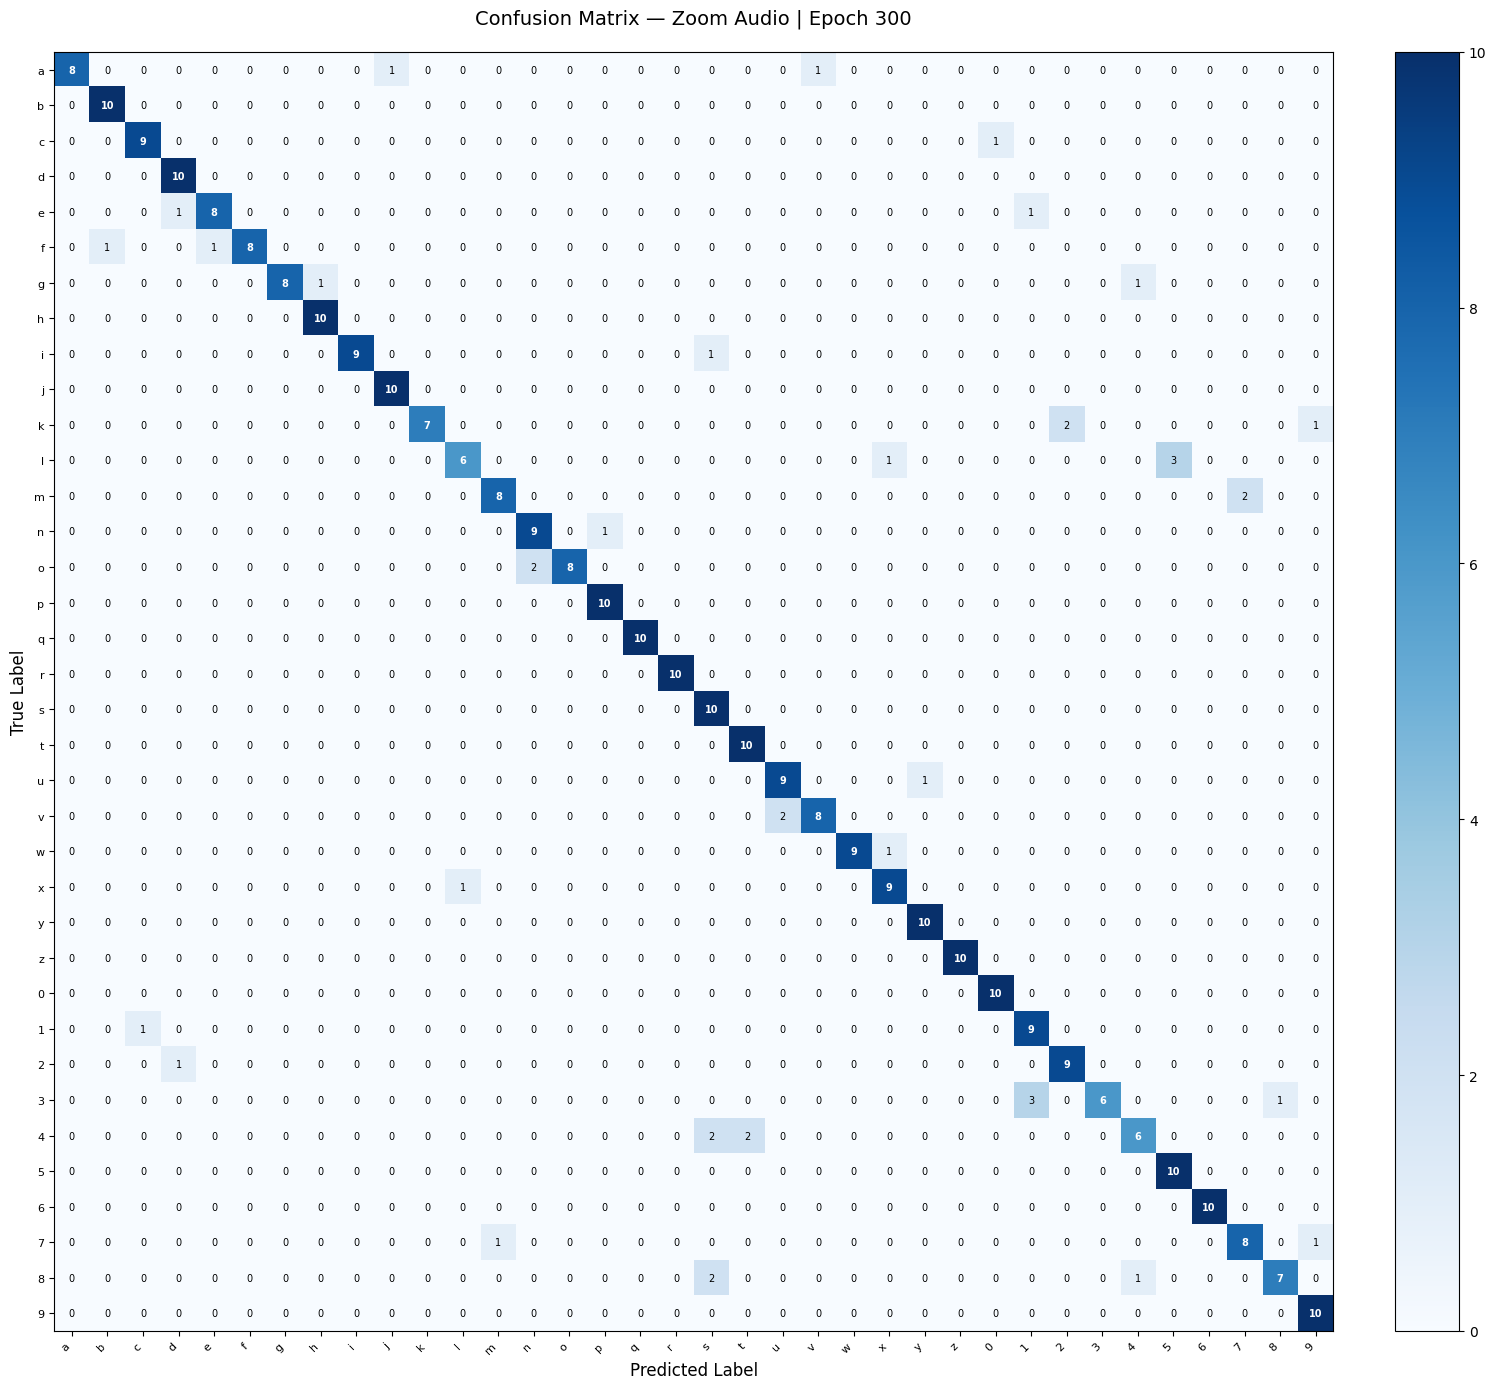

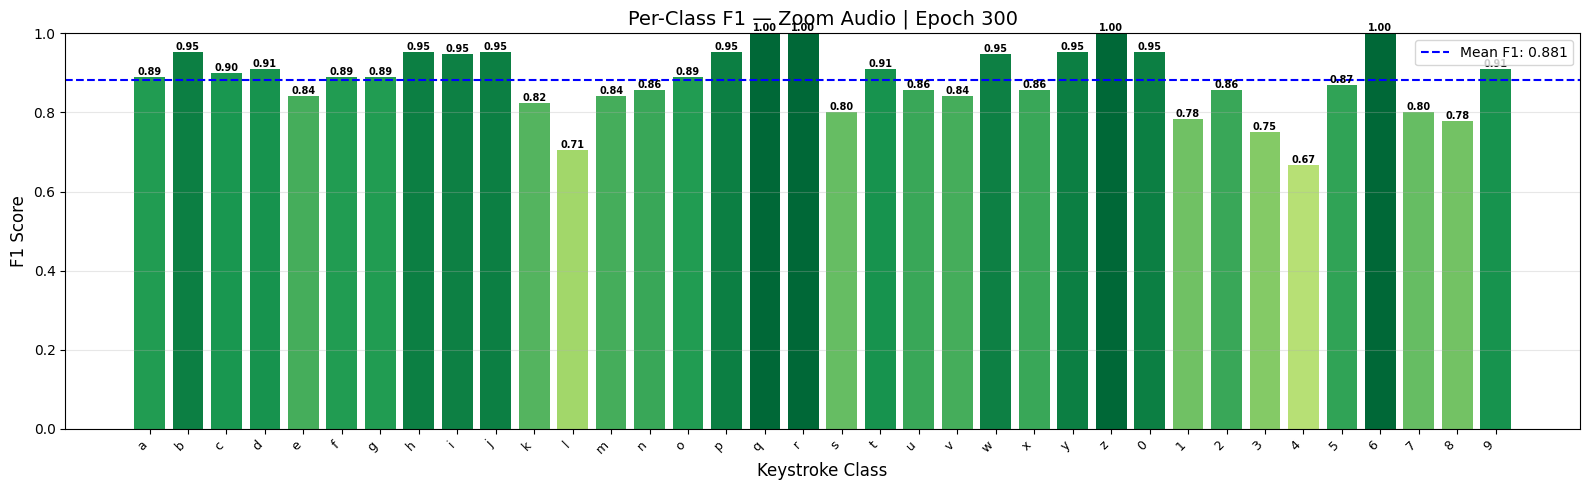

  Time      : 11.11s
  Train     → Loss: 1.6810 | Acc: 0.5815
  Val       → Loss: 1.1715   | Acc: 0.8833
  Weighted  → P: 0.8946 | R: 0.8833 | F1: 0.8812

Epoch 301/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 301
  Accuracy  : 0.9000
  Precision : 0.9083  (weighted)
  Recall    : 0.9000  (weighted)
  F1 Score  : 0.8980  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9000     0.9474         10
  b              0.9091     1.0000     0.9524         10
  c              1.0000     0.9000     0.9474         10
  d              0.9091     1.0000     0.9524         10
  e              0.8750     0.7000     0.7778         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.8000     0.8889         10
  h              0.7692     1.0000     0.8696         10
  i              1.0000     0.8000     0.8889         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     0.6000     0.7500         10
  l              0.8571     0.6000     0.7059         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 302
  Accuracy  : 0.8694
  Precision : 0.8843  (weighted)
  Recall    : 0.8694  (weighted)
  F1 Score  : 0.8663  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.6000     0.7500         10
  b              0.7692     1.0000     0.8696         10
  c              0.8889     0.8000     0.8421         10
  d              0.8333     1.0000     0.9091         10
  e              1.0000     0.6000     0.7500         10
  f              0.6923     0.9000     0.7826         10
  g              0.8889     0.8000     0.8421         10
  h              1.0000     0.9000     0.9474         10
  i              1.0000     0.9000     0.9474         10
  j              0.7692     1.0000     0.8696         10
  k              1.0000     0.7000     0.8235         10
  l              0.8571     0.6000     0.7059         10
  m              0.8


  Validation Results — Zoom Audio | Epoch 303
  Accuracy  : 0.8389
  Precision : 0.8723  (weighted)
  Recall    : 0.8389  (weighted)
  F1 Score  : 0.8319  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.6000     0.7500         10
  b              0.5882     1.0000     0.7407         10
  c              0.8333     0.5000     0.6250         10
  d              0.7692     1.0000     0.8696         10
  e              1.0000     0.5000     0.6667         10
  f              0.6923     0.9000     0.7826         10
  g              1.0000     0.7000     0.8235         10
  h              1.0000     0.9000     0.9474         10
  i              1.0000     0.8000     0.8889         10
  j              0.8182     0.9000     0.8571         10
  k              1.0000     0.8000     0.8889         10
  l              0.8571     0.6000     0.7059         10
  m              0.6


  Validation Results — Zoom Audio | Epoch 304
  Accuracy  : 0.9028
  Precision : 0.9158  (weighted)
  Recall    : 0.9028  (weighted)
  F1 Score  : 0.9015  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9000     0.9474         10
  b              1.0000     1.0000     1.0000         10
  c              1.0000     0.9000     0.9474         10
  d              0.8333     1.0000     0.9091         10
  e              0.8889     0.8000     0.8421         10
  f              1.0000     0.8000     0.8889         10
  g              0.9000     0.9000     0.9000         10
  h              0.8182     0.9000     0.8571         10
  i              1.0000     0.8000     0.8889         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     0.6000     0.7500         10
  l              0.8571     0.6000     0.7059         10
  m              0.8

...


  Validation Results — Zoom Audio | Epoch 396
  Accuracy  : 0.9000
  Precision : 0.9090  (weighted)
  Recall    : 0.9000  (weighted)
  F1 Score  : 0.8974  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.7000     0.8235         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.9000     0.9000     0.9000         10
  e              1.0000     0.7000     0.8235         10
  f              0.8182     0.9000     0.8571         10
  g              1.0000     0.5000     0.6667         10
  h              0.8333     1.0000     0.9091         10
  i              0.8182     0.9000     0.8571         10
  j              0.9091     1.0000     0.9524         10
  k              0.8333     1.0000     0.9091         10
  l              0.8889     0.8000     0.8421         10
  m              0.8


  Validation Results — Zoom Audio | Epoch 397
  Accuracy  : 0.9167
  Precision : 0.9245  (weighted)
  Recall    : 0.9167  (weighted)
  F1 Score  : 0.9167  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.8333     1.0000     0.9091         10
  e              0.8889     0.8000     0.8421         10
  f              1.0000     0.8000     0.8889         10
  g              1.0000     0.9000     0.9474         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.9000     0.9474         10
  l              0.8889     0.8000     0.8421         10
  m              0.8


  Validation Results — Zoom Audio | Epoch 398
  Accuracy  : 0.9139
  Precision : 0.9212  (weighted)
  Recall    : 0.9139  (weighted)
  F1 Score  : 0.9133  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.7000     0.8235         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.9091     1.0000     0.9524         10
  e              1.0000     0.8000     0.8889         10
  f              0.9000     0.9000     0.9000         10
  g              1.0000     0.9000     0.9474         10
  h              1.0000     1.0000     1.0000         10
  i              0.9000     0.9000     0.9000         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.9000     0.9474         10
  l              0.8889     0.8000     0.8421         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 399
  Accuracy  : 0.9083
  Precision : 0.9171  (weighted)
  Recall    : 0.9083  (weighted)
  F1 Score  : 0.9079  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              1.0000     1.0000     1.0000         10
  e              0.8182     0.9000     0.8571         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.7000     0.8235         10
  h              0.8333     1.0000     0.9091         10
  i              1.0000     0.9000     0.9474         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     0.8000     0.8889         10
  l              1.0000     0.7000     0.8235         10
  m              0.8


  Validation Results — Zoom Audio | Epoch 400
  Accuracy  : 0.9056
  Precision : 0.9124  (weighted)
  Recall    : 0.9056  (weighted)
  F1 Score  : 0.9042  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9000     0.9474         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.9091     1.0000     0.9524         10
  e              0.8889     0.8000     0.8421         10
  f              0.9000     0.9000     0.9000         10
  g              1.0000     0.9000     0.9474         10
  h              1.0000     0.9000     0.9474         10
  i              0.9091     1.0000     0.9524         10
  j              0.9091     1.0000     0.9524         10
  k              1.0000     0.7000     0.8235         10
  l              0.8750     0.7000     0.7778         10
  m              0.9

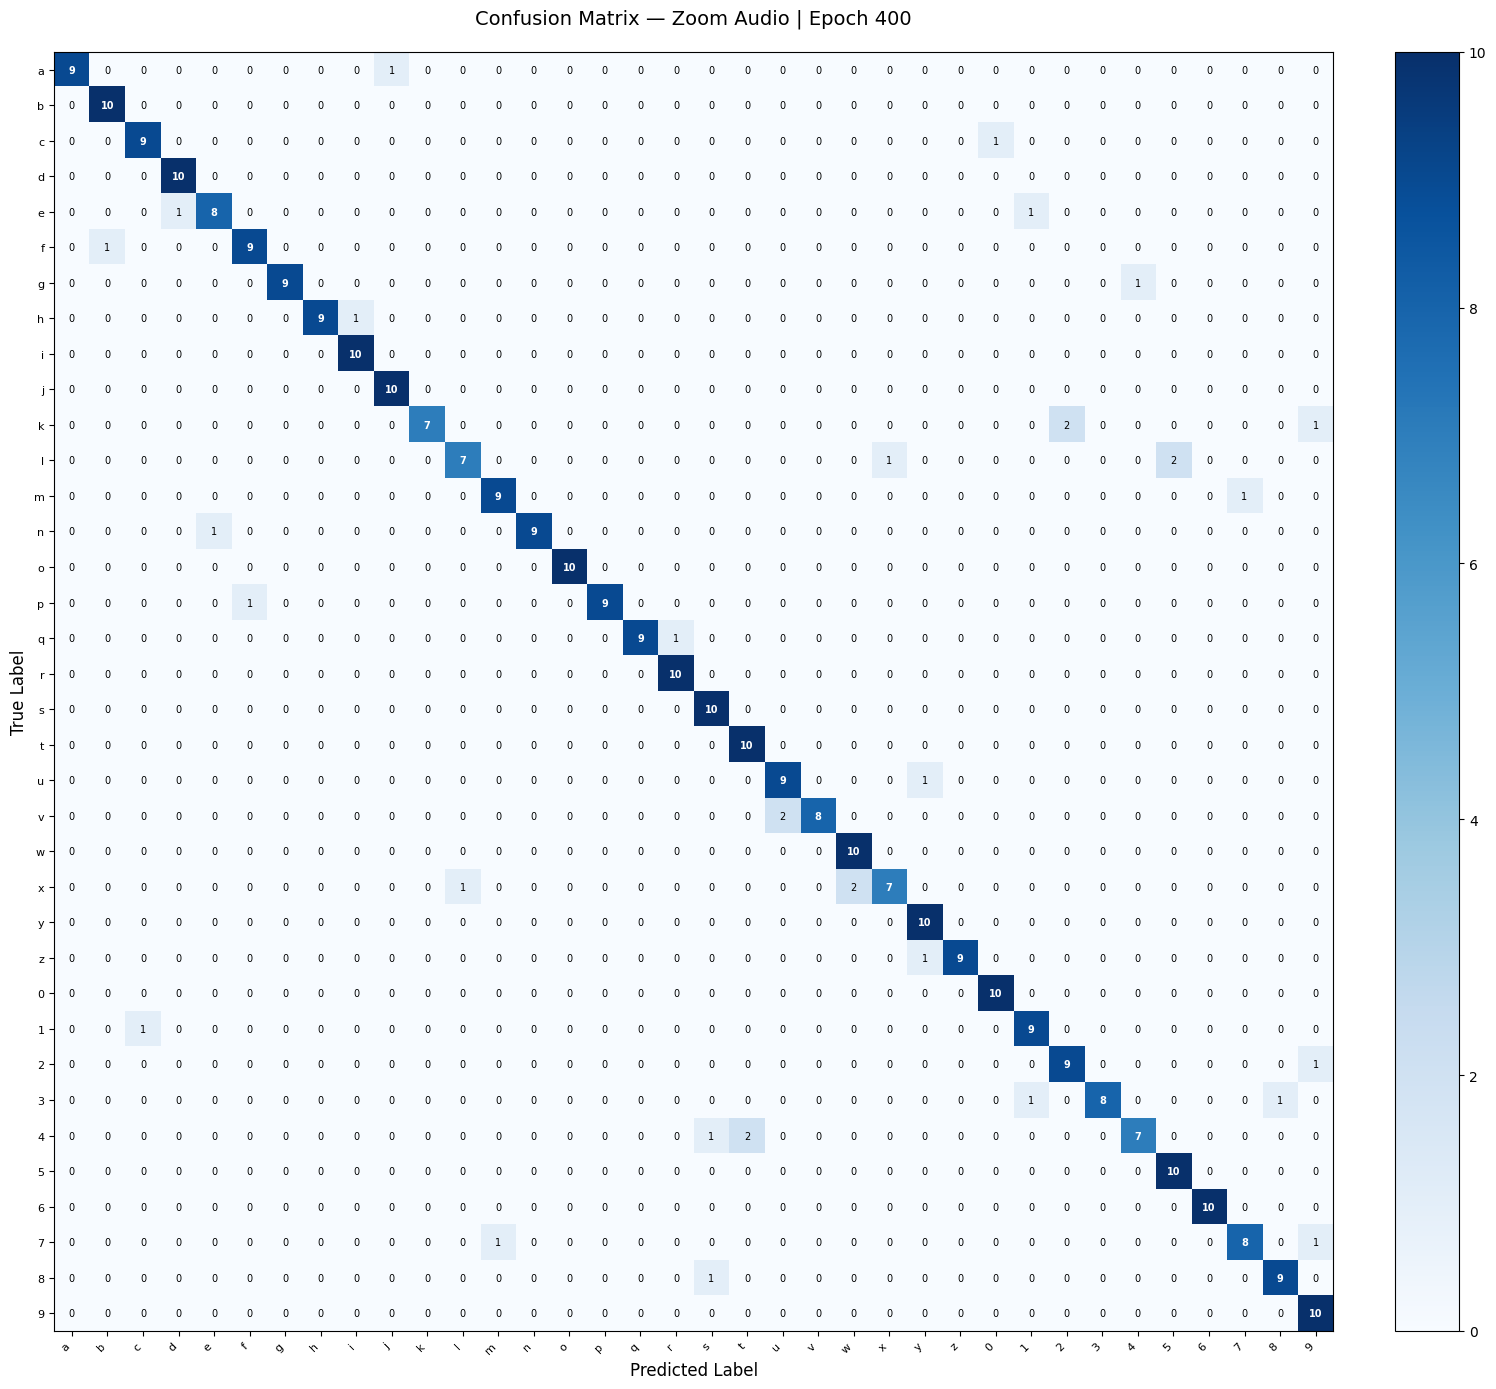

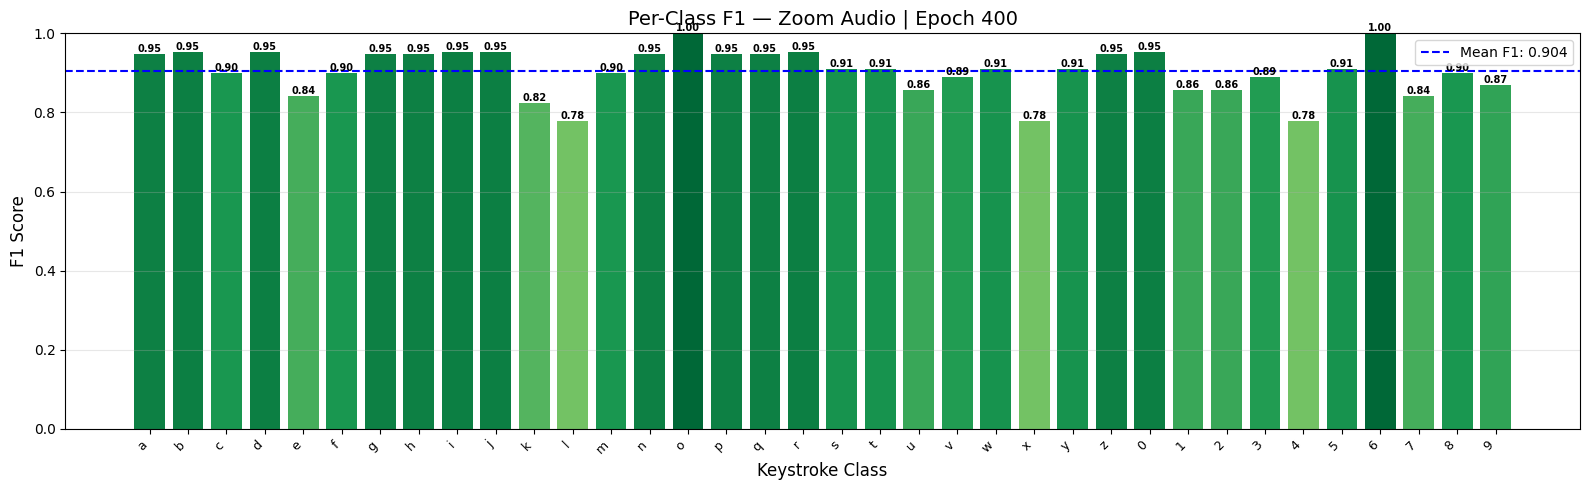

  Time      : 13.07s
  Train     → Loss: 1.5879 | Acc: 0.6463
  Val       → Loss: 1.1144   | Acc: 0.9056
  Weighted  → P: 0.9124 | R: 0.9056 | F1: 0.9042

Epoch 401/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 401
  Accuracy  : 0.9083
  Precision : 0.9175  (weighted)
  Recall    : 0.9083  (weighted)
  F1 Score  : 0.9070  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9000     0.9474         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.8333     1.0000     0.9091         10
  e              0.8750     0.7000     0.7778         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.9000     0.9474         10
  h              0.9091     1.0000     0.9524         10
  i              1.0000     0.9000     0.9474         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     0.7000     0.8235         10
  l              1.0000     0.6000     0.7500         10
  m              0.9


  Validation Results — Zoom Audio | Epoch 402
  Accuracy  : 0.8944
  Precision : 0.9043  (weighted)
  Recall    : 0.8944  (weighted)
  F1 Score  : 0.8929  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              1.0000     0.9000     0.9474         10
  e              0.8750     0.7000     0.7778         10
  f              1.0000     0.8000     0.8889         10
  g              1.0000     0.8000     0.8889         10
  h              0.9091     1.0000     0.9524         10
  i              1.0000     0.9000     0.9474         10
  j              0.9091     1.0000     0.9524         10
  k              1.0000     0.7000     0.8235         10
  l              0.8750     0.7000     0.7778         10
  m              0.8


  Validation Results — Zoom Audio | Epoch 403
  Accuracy  : 0.9056
  Precision : 0.9143  (weighted)
  Recall    : 0.9056  (weighted)
  F1 Score  : 0.9050  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9000     0.9474         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.8333     1.0000     0.9091         10
  e              0.8889     0.8000     0.8421         10
  f              1.0000     0.8000     0.8889         10
  g              1.0000     0.8000     0.8889         10
  h              0.9091     1.0000     0.9524         10
  i              1.0000     0.9000     0.9474         10
  j              1.0000     1.0000     1.0000         10
  k              1.0000     0.7000     0.8235         10
  l              1.0000     0.8000     0.8889         10
  m              0.8


  Validation Results — Zoom Audio | Epoch 404
  Accuracy  : 0.8972
  Precision : 0.9089  (weighted)
  Recall    : 0.8972  (weighted)
  F1 Score  : 0.8964  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.7000     0.8235         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.9091     1.0000     0.9524         10
  e              0.8750     0.7000     0.7778         10
  f              0.6667     0.8000     0.7273         10
  g              1.0000     0.8000     0.8889         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     0.9000     0.9474         10
  j              0.7692     1.0000     0.8696         10
  k              1.0000     0.8000     0.8889         10
  l              0.9000     0.9000     0.9000         10
  m              0.7

...


  Validation Results — Zoom Audio | Epoch 490
  Accuracy  : 0.9139
  Precision : 0.9265  (weighted)
  Recall    : 0.9139  (weighted)
  F1 Score  : 0.9131  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.9091     1.0000     0.9524         10
  e              1.0000     0.8000     0.8889         10
  f              1.0000     0.9000     0.9474         10
  g              1.0000     0.8000     0.8889         10
  h              0.9091     1.0000     0.9524         10
  i              1.0000     1.0000     1.0000         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.7000     0.8235         10
  l              1.0000     0.8000     0.8889         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 491
  Accuracy  : 0.9139
  Precision : 0.9243  (weighted)
  Recall    : 0.9139  (weighted)
  F1 Score  : 0.9124  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8889     0.8000     0.8421         10
  b              1.0000     1.0000     1.0000         10
  c              0.9000     0.9000     0.9000         10
  d              0.8333     1.0000     0.9091         10
  e              0.8182     0.9000     0.8571         10
  f              0.9000     0.9000     0.9000         10
  g              1.0000     0.9000     0.9474         10
  h              1.0000     1.0000     1.0000         10
  i              1.0000     1.0000     1.0000         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.7000     0.8235         10
  l              1.0000     0.9000     0.9474         10
  m              1.0


  Validation Results — Zoom Audio | Epoch 492
  Accuracy  : 0.9083
  Precision : 0.9179  (weighted)
  Recall    : 0.9083  (weighted)
  F1 Score  : 0.9080  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.9091     1.0000     0.9524         10
  e              0.8000     0.8000     0.8000         10
  f              1.0000     0.8000     0.8889         10
  g              1.0000     0.9000     0.9474         10
  h              0.9091     1.0000     0.9524         10
  i              1.0000     0.9000     0.9474         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.7000     0.8235         10
  l              0.8889     0.8000     0.8421         10
  m              0.7


  Validation Results — Zoom Audio | Epoch 493
  Accuracy  : 0.9139
  Precision : 0.9216  (weighted)
  Recall    : 0.9139  (weighted)
  F1 Score  : 0.9131  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.9091     1.0000     0.9524         10
  e              0.8889     0.8000     0.8421         10
  f              0.8889     0.8000     0.8421         10
  g              1.0000     0.8000     0.8889         10
  h              0.8333     1.0000     0.9091         10
  i              1.0000     1.0000     1.0000         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.7000     0.8235         10
  l              0.8750     0.7000     0.7778         10
  m              0.9


  Validation Results — Zoom Audio | Epoch 494
  Accuracy  : 0.9167
  Precision : 0.9256  (weighted)
  Recall    : 0.9167  (weighted)
  F1 Score  : 0.9156  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8000     0.8889         10
  b              0.9091     1.0000     0.9524         10
  c              0.9000     0.9000     0.9000         10
  d              0.9091     1.0000     0.9524         10
  e              0.8889     0.8000     0.8421         10
  f              1.0000     0.8000     0.8889         10
  g              1.0000     0.8000     0.8889         10
  h              0.9000     0.9000     0.9000         10
  i              0.9091     1.0000     0.9524         10
  j              0.8333     1.0000     0.9091         10
  k              1.0000     0.7000     0.8235         10
  l              1.0000     0.8000     0.8889         10
  m              0.9

In [9]:
history = { #this dictionary stores metrics which is later used for the plots and to analyze the progress of the training
    "Phone Audio": {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'weighted_val_precision': [],
        'weighted_val_recall': [],
        'weighted_val_f1': [],
        'learning_rates': []
    },
    "Zoom Audio": {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'weighted_val_precision': [],
        'weighted_val_recall': [],
        'weighted_val_f1': [],
        'learning_rates': []
    }
}

PLOT_EVERY_N_EPOCHS = 100 #Confusion matrix and F1 plots are shown every 100 epochs to save computational time

models = { #bundles each model with its corresponding componenets so both can be training using the same loop
    "Phone Audio": [PhoneAudioModel, PhoneAudioTrainLoader, PhoneAudioValLoader, PhoneAudioOptimizer, PhoneAudioScheduler],
    "Zoom Audio":  [ZoomAudioModel,  ZoomAudioTrainLoader,  ZoomAudioValLoader,  ZoomAudioOptimizer, ZoomAudioScheduler]
}

best_val_f1_tracker = {} #dictionary stores the best validation F1 score for each model

for model_name in models: #loops through each model seperately
    best_val_f1 = 0 #Stores the best validation F1 score seen so far
    best_model_state = None #will stores the best model weights
    model = models[model_name][0] #extracts the model
    train_loader = models[model_name][1] #extracts dataset loader
    val_loader = models[model_name][2] #extracts the validation loader
    optimizer = models[model_name][3] #extracts training optimizer
    scheduler = models[model_name][4] #extracts the learning rate scheduler
    earlyStopper = EarlyStopping(patience=100) #the early stopper which stops training if the F1 score isn't improving for every 100 epoch to reduce training time and prevent overfitting

    print("\n" + "=" * 60) #seperator
    print(f"  STARTING TRAINING: {model_name}")
    print("=" * 60) #seperator
    print(f"  Epochs     : {NUM_EPOCHS}")
    print(f"  Device     : {device}")
    print(f"  Parameters : {model.get_num_params():,}")
    print("=" * 60)

    for epoch in range(NUM_EPOCHS): #main training loop
        start_time = time.time() #records the time at the beginning of each loop to measure the duration
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 60) #prints line seperator

        """Training Phrase"""
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device, use_mixup=True)

        """Validating Phrase"""
        show_plots = ((epoch + 1) % PLOT_EVERY_N_EPOCHS == 0) or (epoch + 1 == NUM_EPOCHS)
        (val_loss, val_acc,
         precision_per_class, recall_per_class, f1_per_class, support_per_class,
         precision_weighted, recall_weighted, f1_weighted) = validate(
            model, val_loader, criterion, device,
            num_classes = 36,
            show_plots  = show_plots,
            epoch       = epoch + 1,
            model_name  = model_name
        )

        scheduler.step()
        earlyStopper.step(f1_weighted) # Update F1 score to check for plateau

        """Logging History"""
        current_lr = optimizer.param_groups[0]['lr'] #retrieves the current learning rate from the optimizer
        history[model_name]['train_loss'].append(train_loss) #stores training loss
        history[model_name]['train_acc'].append(train_acc) #stores training accuracy
        history[model_name]['val_loss'].append(val_loss) #stores validation loss
        history[model_name]['val_acc'].append(val_acc) #stores validation accuracy
        history[model_name]['weighted_val_precision'].append(precision_weighted) #stores precision (True Positives/Total)
        history[model_name]['weighted_val_recall'].append(recall_weighted)
        history[model_name]['weighted_val_f1'].append(f1_weighted)
        history[model_name]['learning_rates'].append(current_lr)

        """Saving Best Model"""
        if f1_weighted > best_val_f1:
            best_val_f1 = f1_weighted
            best_model_state = model.state_dict().copy()
            print(f"  ★ New best Weighted F1: {f1_weighted:.4f}")

        epoch_time = time.time() - start_time
        print(f"  Time      : {epoch_time:.2f}s") #Epoch Summary
        print(f"  Train     → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"  Val       → Loss: {val_loss:.4f}   | Acc: {val_acc:.4f}")
        print(f"  Weighted  → P: {precision_weighted:.4f} | R: {recall_weighted:.4f} | F1: {f1_weighted:.4f}")

        if earlyStopper.should_stop: #if no improvement in F1, it stops to avoid wasting time and resources
            break

    """Load Best Weights"""
    if best_model_state is not None: #loads the best weight in case the last ones weren't the best
        model.load_state_dict(best_model_state)
        print(f"\n✓ Loaded best {model_name} weights  (F1: {best_val_f1:.4f})") #prints the best weights/F1

    best_val_f1_tracker[model_name] = best_val_f1 #saves the best validation F1 score for that model

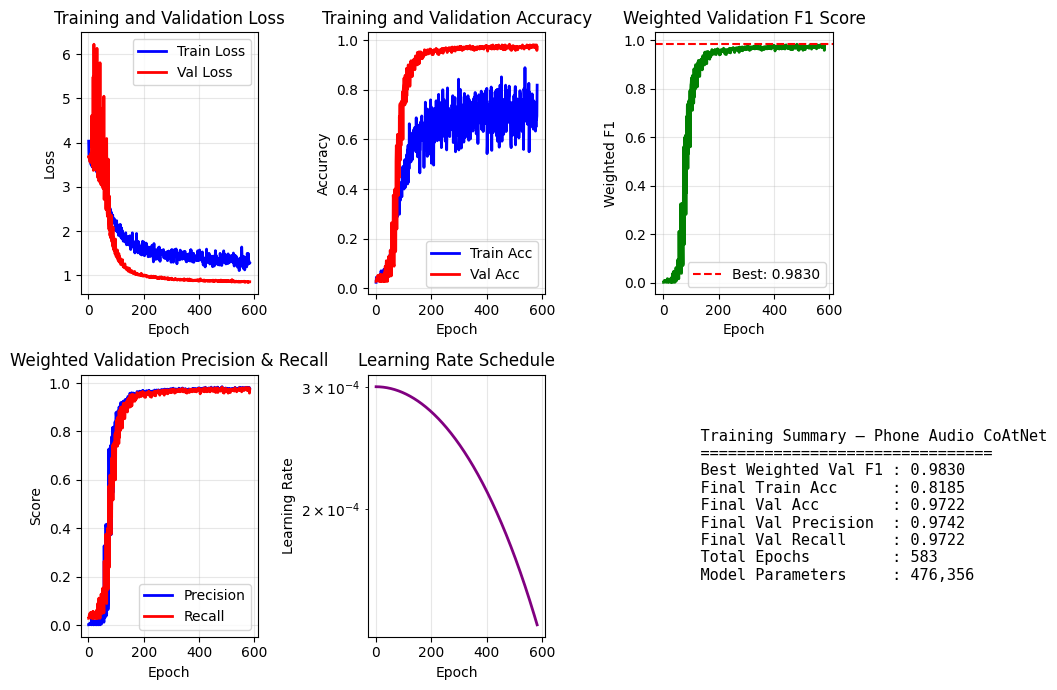

In [10]:
plot_training_history(history["Phone Audio"], "Phone Audio CoAtNet", PhoneAudioModel, best_val_f1_tracker["Phone Audio"]) #generates the function that generates the graphs for the phone audio model, such as F1 score over epochs, training VS validation accuracys and losses, precision & recall and learning rate schedule; overall to analyze how the model learned during training

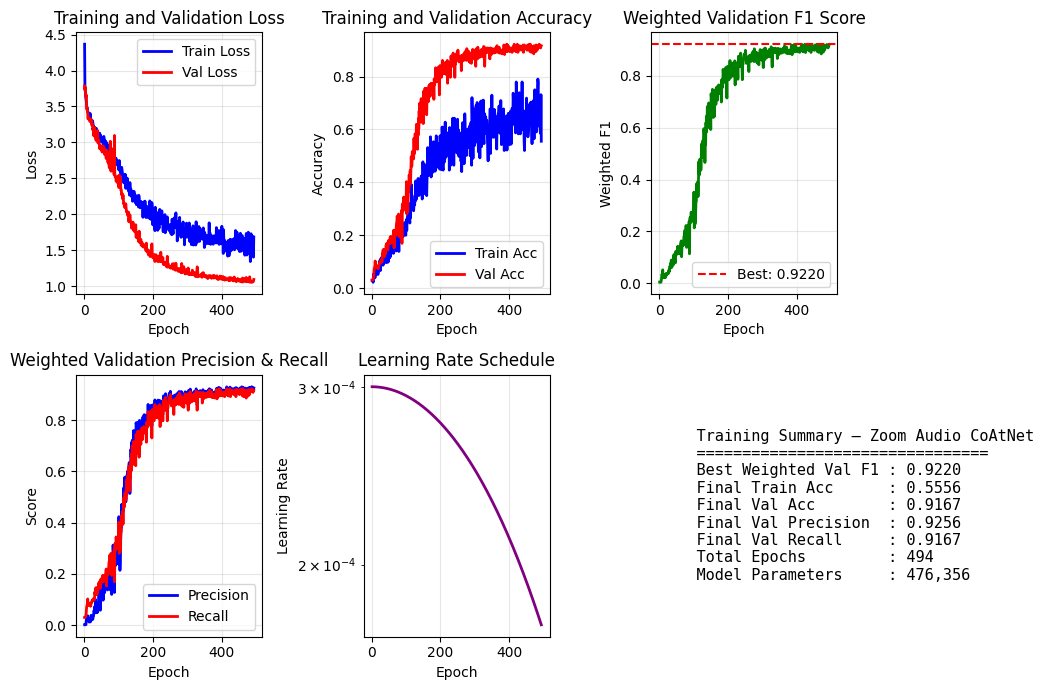

In [11]:
plot_training_history(history["Zoom Audio"],  "Zoom Audio CoAtNet", ZoomAudioModel,  best_val_f1_tracker["Zoom Audio"]) #generates the function that generates the graphs for the zoom audio model, such as F1 score over epochs, training VS validation accuracys and losses, precision & recall and learning rate schedule; overall to analyze how the model learned during training

### Save Model

In [12]:
models = {"PhoneAudioCoATnet": PhoneAudioModel, "ZoomAudioCoATnet": ZoomAudioModel} #puts both trained models into a dictionary to be accessed later

for modelName in models: #loops through each model in the dictionary
    model_save_path = f'{modelName}.pth' #creates a file name where it will be saved
    model = models[modelName] #grabs the model object from the dictionary
    torch.save(model.state_dict(), model_save_path) #saves trained weights of the neural network
    print(f"\n✓ Model saved to: {model_save_path}") #prints the path in which it was saved to


✓ Model saved to: PhoneAudioCoATnet.pth

✓ Model saved to: ZoomAudioCoATnet.pth
